Building abstraction...
Abstraction built: 900 states
Obj1: Safe set size = 900
Reachability fixed point reached in 15 iterations, |R| = 836
✅ Reached target at step 20
✅ Trajectory from [8.5, 8.5] reached R3
✅ Reached target at step 13
✅ Trajectory from [9.0, 1.5] reached R3
✅ Reached target at step 14
✅ Trajectory from [7.0, 7.0] reached R3
Phase transition: q0 -> q1 at step 8
Phase transition: q3 -> q3 at step 21
✅ Temporal spec satisfied at step 21
Phase transition: q0 -> q2 at step 2
Phase transition: q3 -> q3 at step 14
✅ Temporal spec satisfied at step 14
Reachability fixed point reached in 11 iterations, |R| = 900
✅ Reached target at step 10
✅ Simple reach from [8.5, 8.5] succeeded
✅ Reached target at step 14
✅ Simple reach from [9.0, 9.0] succeeded
✅ Reached target at step 11
✅ Simple reach from [5.0, 8.0] succeeded


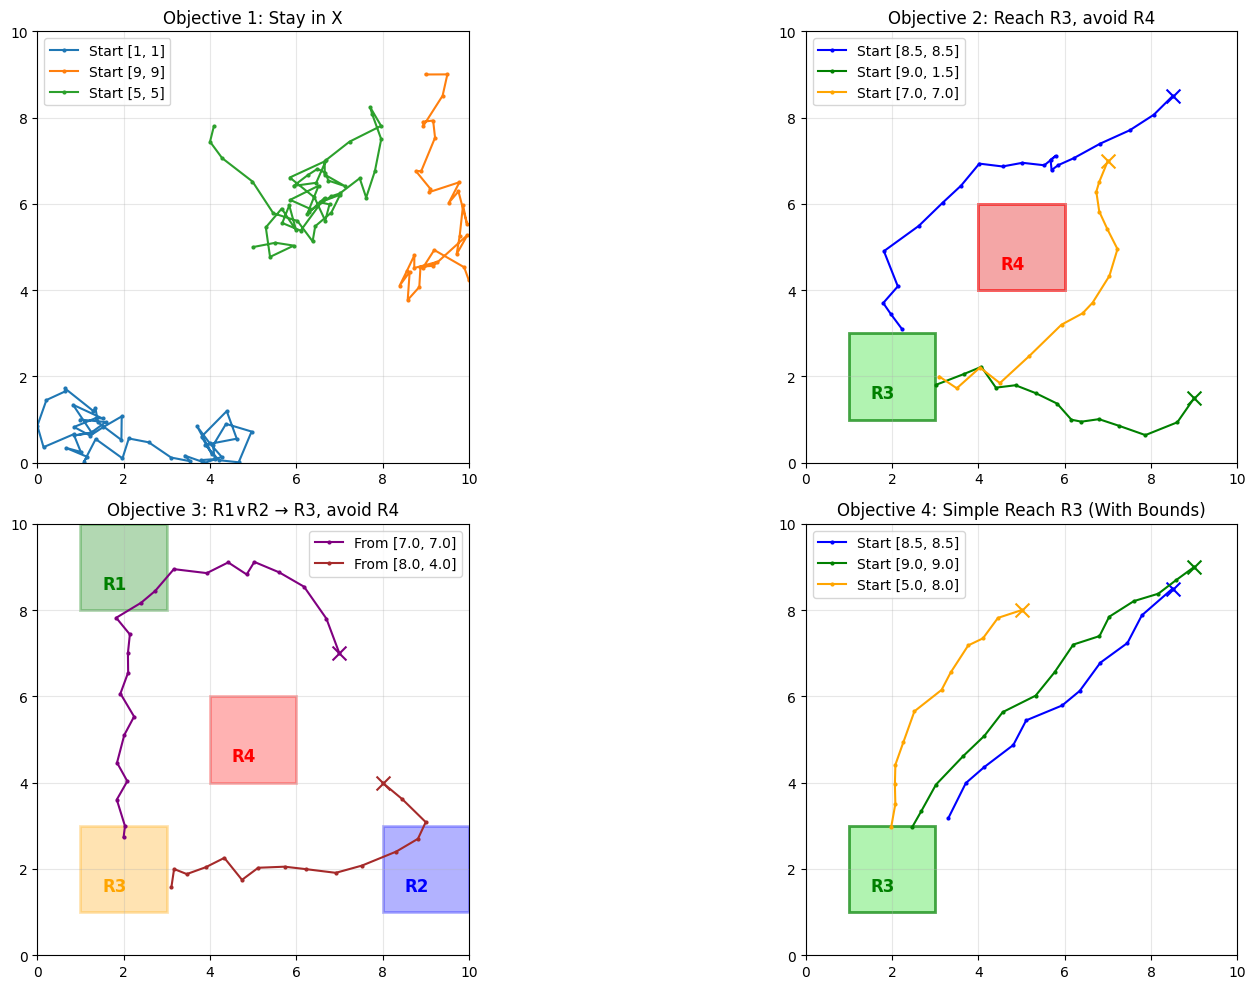

In [1]:
import numpy as np
import itertools
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helpers
# =========================================================

def interval_to_arrays(interval):
    low = np.array([interval[0][0], interval[1][0]], dtype=float)
    high = np.array([interval[0][1], interval[1][1]], dtype=float)
    return low, high

def transitions_to_dict(transitions):
    td = defaultdict(list)
    for state, control, successors in transitions:
        td[state].append((control, successors))
    return dict(td)

# =========================================================
# 1) 2D Robot abstraction (Point Mass Model)
# =========================================================

class RobotAbstraction:
    def __init__(self, state_intervals, control_values, perturbation, delta_t,
                 discrete_x_y=80, v_vals=5):
        self.state_intervals = state_intervals
        self.control_values = control_values
        self.perturbation = perturbation
        self.delta_t = delta_t
        self.discrete_x_y = discrete_x_y
        self.v_vals = v_vals

        self.state_edges = []
        self.state_to_index = {}
        self.index_to_intervals = {}
        self.cell_centers = []

        self._create_state_mapping()

    def _create_state_mapping(self):
        self.state_edges = [
            np.linspace(self.state_intervals[0][0], self.state_intervals[0][1], self.discrete_x_y + 1),
            np.linspace(self.state_intervals[1][0], self.state_intervals[1][1], self.discrete_x_y + 1)
        ]

        idx = 1
        for i in range(self.discrete_x_y):
            for j in range(self.discrete_x_y):
                x_low, x_high = self.state_edges[0][i], self.state_edges[0][i+1]
                y_low, y_high = self.state_edges[1][j], self.state_edges[1][j+1]
                center = (0.5*(x_low + x_high), 0.5*(y_low + y_high))

                self.cell_centers.append(center)
                self.state_to_index[(i+1, j+1)] = idx
                self.index_to_intervals[idx] = [(x_low, x_high), (y_low, y_high)]
                idx += 1

    def dynamics(self, x, v, w):
        x = np.array(x, dtype=float)
        v = np.array(v, dtype=float)
        w = np.array(w, dtype=float)
        x_next = x + self.delta_t * (v + w)
        x_next[0] = np.clip(x_next[0], self.state_intervals[0][0], self.state_intervals[0][1])
        x_next[1] = np.clip(x_next[1], self.state_intervals[1][0], self.state_intervals[1][1])
        return x_next

    def monotone_overapprox(self, x_min, x_max, v):
        w_min = np.array([self.perturbation[0][0], self.perturbation[1][0]])
        w_max = np.array([self.perturbation[0][1], self.perturbation[1][1]])

        state_corners = [
            np.array([x_min[0], x_min[1]]),
            np.array([x_min[0], x_max[1]]),
            np.array([x_max[0], x_min[1]]),
            np.array([x_max[0], x_max[1]])
        ]
        pert_corners = [
            np.array([w_min[0], w_min[1]]),
            np.array([w_min[0], w_max[1]]),
            np.array([w_max[0], w_min[1]]),
            np.array([w_max[0], w_max[1]])
        ]

        results = []
        for s in state_corners:
            for w in pert_corners:
                res = self.dynamics(s, v, w)
                results.append(res)
        results = np.array(results)
        next_min = results.min(axis=0)
        next_max = results.max(axis=0)

        next_min[0] = max(next_min[0], self.state_intervals[0][0])
        next_min[1] = max(next_min[1], self.state_intervals[1][0])
        next_max[0] = min(next_max[0], self.state_intervals[0][1])
        next_max[1] = min(next_max[1], self.state_intervals[1][1])

        return next_min, next_max

    def _find_state(self, x):
        i = np.digitize(x[0], self.state_edges[0]) - 1
        j = np.digitize(x[1], self.state_edges[1]) - 1
        if 0 <= i < self.discrete_x_y and 0 <= j < self.discrete_x_y:
            return self.state_to_index.get((i+1, j+1), -1)
        return -1

    def compute_transitions(self):
        transitions = []
        vx_vals = np.linspace(self.control_values[0][0], self.control_values[0][1], self.v_vals)
        vy_vals = np.linspace(self.control_values[1][0], self.control_values[1][1], self.v_vals)
        control_grid = list(itertools.product(vx_vals, vy_vals))

        for idx, center in enumerate(self.cell_centers, start=1):
            interval = self.index_to_intervals[idx]
            x_min, x_max = interval_to_arrays(interval)

            for control in control_grid:
                next_min, next_max = self.monotone_overapprox(x_min, x_max, control)
                successors = set()
                xs = np.linspace(next_min[0], next_max[0], 5)
                ys = np.linspace(next_min[1], next_max[1], 5)
                for px, py in itertools.product(xs, ys):
                    s_idx = self._find_state((px, py))
                    if s_idx != -1:
                        successors.add(s_idx)
                transitions.append((idx, control, successors))
        return transitions

    def find_indices_for_interval(self, region):
        indices = []
        for idx, interval in self.index_to_intervals.items():
            overlap = True
            for dim in range(2):
                if not (region[dim][1] >= interval[dim][0] and region[dim][0] <= interval[dim][1]):
                    overlap = False
                    break
            if overlap:
                indices.append(idx)
        return indices

# =========================================================
# 2) Symbolic Synthesis Tools
# =========================================================

class SafetySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ and succ.issubset(R):
                pre_set.add(s)
        return pre_set

    def synthesize(self, safe_set):
        R = set(safe_set)
        while True:
            R_new = R & self.pre(R)
            if R_new == R:
                break
            R = R_new
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and succ and succ.issubset(R):
                controller[s].add(u)
        return R, dict(controller)

class ReachabilitySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ & R:
                pre_set.add(s)
        return pre_set

    def synthesize(self, target_set, safe_set):
        R = set(target_set) & set(safe_set)
        changed = True
        iterations = 0
        
        while changed and iterations < 1000:
            changed = False
            pre_R = self.pre(R)
            new_states = (pre_R & set(safe_set)) - R
            if new_states:
                R |= new_states
                changed = True
            iterations += 1
            
        print(f"Reachability fixed point reached in {iterations} iterations, |R| = {len(R)}")
        
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and (succ & R) and s in safe_set:
                controller[s].add(u)
                
        return R, dict(controller)

# =========================================================
# 3) Improved Simulation with Path Planning
# =========================================================

def find_symbolic_path(start_state, target_set, transitions_dict, robot, avoid_set=None):
    """BFS to find path avoiding certain states"""
    start_idx = robot._find_state(tuple(start_state))
    if start_idx == -1:
        return None

    if start_idx in target_set:
        return [start_idx]

    queue = deque([start_idx])
    parent = {start_idx: None}
    
    while queue:
        s = queue.popleft()

        if s in target_set:
            path = []
            while s is not None:
                path.append(s)
                s = parent[s]
            return list(reversed(path))

        for control, successors in transitions_dict.get(s, []):
            for succ in successors:
                if succ not in parent:
                    # Skip states in avoid_set if specified
                    if avoid_set and succ in avoid_set:
                        continue
                    parent[succ] = s
                    queue.append(succ)

    return None

def simulate_with_path_planning(initial_state, controller_dict, robot, target_region=None, 
                               avoid_region=None, max_steps=200, disturbance_std=0.03):
    """Improved simulation that uses path planning to avoid getting stuck"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Convert regions to state indices
    target_indices = set(robot.find_indices_for_interval(target_region)) if target_region else set()
    avoid_indices = set(robot.find_indices_for_interval(avoid_region)) if avoid_region else set()
    
    # Find symbolic path once at beginning
    symbolic_path = None
    if target_region:
        symbolic_path = find_symbolic_path(initial_state, target_indices, 
                                         transitions_to_dict(robot.compute_transitions()), 
                                         robot, avoid_indices)
    
    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in controller_dict or not controller_dict[s_idx]:
            break
            
        if target_region and region_contains_point(x, target_region, robot):
            print(f"✅ Reached target at step {step}")
            break
            
        # Choose control based on path planning
        best_u = None
        best_score = float('inf')
        
        for u in controller_dict[s_idx]:
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            center_next = (next_min + next_max) / 2
            
            score = 0
            
            # Target seeking
            if target_region:
                target_center = np.array([
                    (target_region[0][0] + target_region[0][1]) / 2,
                    (target_region[1][0] + target_region[1][1]) / 2
                ])
                score += np.linalg.norm(center_next - target_center) * 2.0
            
            # Obstacle avoidance (heavier penalty)
            if avoid_region:
                avoid_center = np.array([
                    (avoid_region[0][0] + avoid_region[0][1]) / 2,
                    (avoid_region[1][0] + avoid_region[1][1]) / 2
                ])
                avoid_dist = np.linalg.norm(center_next - avoid_center)
                if avoid_dist < 2.0:  # If too close to obstacle
                    score += 10.0 / (avoid_dist + 0.1)  # Strong repulsion
            
            # Follow symbolic path if available
            if symbolic_path and step < len(symbolic_path):
                target_idx = symbolic_path[min(step + 1, len(symbolic_path) - 1)]
                target_iv = robot.index_to_intervals[target_idx]
                target_cell_center = np.array([
                    (target_iv[0][0] + target_iv[0][1]) / 2,
                    (target_iv[1][0] + target_iv[1][1]) / 2
                ])
                path_score = np.linalg.norm(center_next - target_cell_center)
                score += path_score * 0.5
            
            if score < best_score:
                best_score = score
                best_u = u
                
        if best_u is None:
            best_u = random.choice(list(controller_dict[s_idx]))
            
        # Apply dynamics with bounds enforcement
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Sample within bounds
        x = np.random.uniform(next_min, next_max)
        x += np.random.normal(0, disturbance_std, size=2)
        
        # STRICT bounds enforcement
        x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
        x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
        
        traj.append(list(x))
        
    return traj

def region_contains_point(point, region, robot):
    s = robot._find_state(point)
    region_indices = robot.find_indices_for_interval(region)
    return s in region_indices

def simulate_temporal(initial_state, robot, transitions_dict, R1, R2, R3, R4, max_steps=200):
    """Temporal logic simulation (unchanged from first code)"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Define phases based on the automaton
    phase = "q0"
    R1_indices = set(robot.find_indices_for_interval(R1))
    R2_indices = set(robot.find_indices_for_interval(R2))
    R3_indices = set(robot.find_indices_for_interval(R3))
    R4_indices = set(robot.find_indices_for_interval(R4))
    safe_states = set(robot.index_to_intervals.keys()) - R4_indices

    # Build safe controller first
    synth = SafetySynthesizer(robot.compute_transitions())
    safe_set, safe_controller = synth.synthesize(safe_states)

    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in safe_controller:
            break

        # Update phase based on current state
        if phase == "q0":
            if region_contains_point(x, R1, robot):
                phase = "q1"
                print(f"Phase transition: q0 -> q1 at step {step}")
            elif region_contains_point(x, R2, robot):
                phase = "q2"
                print(f"Phase transition: q0 -> q2 at step {step}")
        elif phase in ["q1", "q2"]:
            if region_contains_point(x, R3, robot):
                phase = "q3"
                print(f"Phase transition: {phase} -> q3 at step {step}")

        # Select control based on phase
        best_u = None
        best_score = float('inf')
        
        for u in safe_controller[s_idx]:
            # Estimate next state region
            interval = robot.index_to_intervals[s_idx]
            x_min, x_max = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(x_min, x_max, u)
            center_next = (next_min + next_max) / 2

            # Calculate score based on phase
            if phase == "q0":
                # Go to nearest of R1 or R2
                r1_center = np.array([(R1[0][0] + R1[0][1])/2, (R1[1][0] + R1[1][1])/2])
                r2_center = np.array([(R2[0][0] + R2[0][1])/2, (R2[1][0] + R2[1][1])/2])
                d1 = np.linalg.norm(center_next - r1_center)
                d2 = np.linalg.norm(center_next - r2_center)
                score = min(d1, d2)
                
            elif phase == "q1":
                # Go to R3, avoid R2
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Penalty for entering R2
                if any(robot._find_state(center_next) in R2_indices for _ in range(1)):
                    score += 10.0
                    
            elif phase == "q2":
                # Go to R3, avoid R1
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Penalty for entering R1
                if any(robot._find_state(center_next) in R1_indices for _ in range(1)):
                    score += 10.0
                    
            else:  # phase == "q3"
                # We've succeeded, just maintain position
                score = 0

            if score < best_score:
                best_score = score
                best_u = u

        if best_u is None:
            best_u = random.choice(list(safe_controller[s_idx]))

        # Apply dynamics
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        x = np.random.uniform(next_min, next_max)
        x += np.random.normal(0, 0.03, size=2)
        x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                    [robot.state_intervals[0][1], robot.state_intervals[1][1]])
        traj.append(list(x))

        # Check for success
        if phase == "q3":
            print(f"✅ Temporal spec satisfied at step {step}")
            break

    return traj, {'final_phase': phase}

# =========================================================
# MAIN - Combined version
# =========================================================

def main():
    # Parameters for 2D system
    state_intervals = [(0, 10), (0, 10)]
    control_values = [(-1.0, 1.0), (-1.0, 1.0)]
    perturbation = [(-0.05, 0.05), (-0.05, 0.05)]
    delta_t = 0.5

    print("Building abstraction...")
    robot = RobotAbstraction(
        state_intervals, control_values, perturbation, delta_t,
        discrete_x_y=30, v_vals=5
    )
    transitions = robot.compute_transitions()
    transitions_dict = transitions_to_dict(transitions)
    print(f"Abstraction built: {len(robot.index_to_intervals)} states")

    # Define geometric regions 
    R1_geom = [(1, 3), (8, 10)]      # Top-left
    R2_geom = [(8, 10), (1, 3)]      # Bottom-right  
    R3_geom = [(1, 3), (1, 3)]       # Bottom-left
    R4_geom = [(4, 6), (4, 6)]       # Center (obstacle)

    # Convert to sets of state indices
    R1_indices = set(robot.find_indices_for_interval(R1_geom))
    R2_indices = set(robot.find_indices_for_interval(R2_geom))
    R3_indices = set(robot.find_indices_for_interval(R3_geom))
    R4_indices = set(robot.find_indices_for_interval(R4_geom))

    all_states = set(robot.index_to_intervals.keys())

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # ===== Objective 1: Safety in X (using original approach) =====
    safe_set1 = all_states
    synth1 = SafetySynthesizer(transitions)
    R1_star, ctrl1 = synth1.synthesize(safe_set1)
    print(f"Obj1: Safe set size = {len(R1_star)}")

    # Plot Obj1 - using original simulation for Objective 1
    axs[0, 0].set_title("Objective 1: Stay in X")
    for start in [[1,1], [9,9], [5,5]]:
        # Use simple simulation for Objective 1 (as in first code)
        traj = []
        x = np.array(start, dtype=float)
        for _ in range(50):  # Fixed number of steps for wandering
            s_idx = robot._find_state(x)
            if s_idx == -1 or s_idx not in ctrl1 or not ctrl1[s_idx]:
                break
            u = random.choice(list(ctrl1[s_idx]))
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
            x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
            traj.append(list(x))
        arr = np.array(traj)
        axs[0, 0].plot([start[0]] + arr[:,0].tolist(), [start[1]] + arr[:,1].tolist(), 
                       '-o', markersize=2, label=f'Start {start}')
    axs[0, 0].set_xlim(state_intervals[0])
    axs[0, 0].set_ylim(state_intervals[1])
    axs[0, 0].set_aspect('equal')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # ===== Objective 2: Reach R3 while avoiding R4 (using improved approach) =====
    safe_set2 = all_states - R4_indices
    synth2 = ReachabilitySynthesizer(transitions)
    R2_reach, ctrl2 = synth2.synthesize(R3_indices, safe_set2)

    # Test multiple starting positions
    starts_obj2 = [[8.5, 8.5], [9.0, 1.5], [7.0, 7.0]]
    colors = ['blue', 'green', 'orange']
    
    axs[0, 1].set_title("Objective 2: Reach R3, avoid R4")
    rect_r3 = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    rect_r4 = patches.Rectangle(
        (R4_geom[0][0], R4_geom[1][0]),
        R4_geom[0][1] - R4_geom[0][0],
        R4_geom[1][1] - R4_geom[1][0],
        linewidth=2, edgecolor='red', facecolor='lightcoral', alpha=0.7
    )
    axs[0, 1].add_patch(rect_r3)
    axs[0, 1].add_patch(rect_r4)
    axs[0, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    axs[0, 1].text(R4_geom[0][0] + 0.5, R4_geom[1][0] + 0.5, 'R4', color='red', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj2):
        if robot._find_state(start) in R2_reach:
            # Use improved path planning with obstacle avoidance
            traj = simulate_with_path_planning(start, ctrl2, robot, target_region=R3_geom, avoid_region=R4_geom)
            arr = np.array(traj)
            axs[0, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors[i], label=f'Start {start}')
            axs[0, 1].scatter(start[0], start[1], c=colors[i], s=100, marker='x')
            
            # Check if trajectory reached target
            if any(region_contains_point(point, R3_geom, robot) for point in traj):
                print(f"✅ Trajectory from {start} reached R3")
            else:
                print(f"❌ Trajectory from {start} did not reach R3")
        else:
            print(f"⚠️  Start {start} not in reachable set")
    
    axs[0, 1].set_xlim(state_intervals[0])
    axs[0, 1].set_ylim(state_intervals[1])
    axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # ===== Objective 3: Temporal logic (unchanged from first code) =====
    start3a = [7.0, 7.0]
    start3b = [8.0, 4.0]

    axs[1, 0].set_title("Objective 3: R1∨R2 → R3, avoid R4")
    for geom, color, label in [(R1_geom, 'green', 'R1'), (R2_geom, 'blue', 'R2'), 
                              (R3_geom, 'orange', 'R3'), (R4_geom, 'red', 'R4')]:
        rect = patches.Rectangle(
            (geom[0][0], geom[1][0]),
            geom[0][1] - geom[0][0],
            geom[1][1] - geom[1][0],
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.3
        )
        axs[1, 0].add_patch(rect)
        axs[1, 0].text(geom[0][0] + 0.5, geom[1][0] + 0.5, label, color=color, 
                       fontsize=12, fontweight='bold')
    
    traj3a, info3a = simulate_temporal(start3a, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    traj3b, info3b = simulate_temporal(start3b, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    
    for traj, start, col in [(traj3a, start3a, 'purple'), (traj3b, start3b, 'brown')]:
        arr = np.array(traj)
        axs[1, 0].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=col, label=f'From {start}')
        axs[1, 0].scatter(start[0], start[1], c=col, s=100, marker='x')
    
    axs[1, 0].set_xlim(state_intervals[0])
    axs[1, 0].set_ylim(state_intervals[1])
    axs[1, 0].set_aspect('equal')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].legend()

    # ===== Objective 4: Simple Reachability (using improved bounds enforcement) =====
    synth4 = ReachabilitySynthesizer(transitions)
    R4_reach, ctrl4 = synth4.synthesize(R3_indices, all_states)

    # Test multiple starts for simple reachability
    starts_obj4 = [[8.5, 8.5], [9.0, 9.0], [5.0, 8.0]]
    colors_obj4 = ['blue', 'green', 'orange']
    
    axs[1, 1].set_title("Objective 4: Simple Reach R3 (With Bounds)")
    rect_r3_simple = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    axs[1, 1].add_patch(rect_r3_simple)
    axs[1, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj4):
        if robot._find_state(start) in R4_reach:
            # Use improved simulation with strict bounds enforcement
            traj = simulate_with_path_planning(start, ctrl4, robot, target_region=R3_geom)
            arr = np.array(traj)
            axs[1, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors_obj4[i], label=f'Start {start}')
            axs[1, 1].scatter(start[0], start[1], c=colors_obj4[i], s=100, marker='x')
            
            # Check if trajectory reached target
            if any(region_contains_point(point, R3_geom, robot) for point in traj):
                print(f"✅ Simple reach from {start} succeeded")
            else:
                print(f"❌ Simple reach from {start} failed")
        else:
            print(f"⚠️  Start {start} not in simple reachable set")
    
    axs[1, 1].set_xlim(state_intervals[0])
    axs[1, 1].set_ylim(state_intervals[1])
    axs[1, 1].set_aspect('equal')
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Building abstraction...
Abstraction built: 900 states
Obj1: Safe set size = 900
Reachability fixed point reached in 15 iterations, |R| = 836
✅ Reached and stayed in target at step 13
✅ Trajectory from [8.5, 8.5] reached R3
✅ Reached and stayed in target at step 11
✅ Trajectory from [9.0, 1.5] reached R3
✅ Reached and stayed in target at step 13
✅ Trajectory from [7.0, 7.0] reached R3
Phase transition: q0 -> q1 at step 8
Phase transition: q3 -> q3 at step 15
✅ Temporal spec satisfied at step 15
Phase transition: q0 -> q2 at step 3
Phase transition: q3 -> q3 at step 10
✅ Temporal spec satisfied at step 10
Reachability fixed point reached in 11 iterations, |R| = 900
✅ Reached and stayed in target at step 10
✅ Simple reach from [8.5, 8.5] succeeded
✅ Reached and stayed in target at step 12
✅ Simple reach from [9.0, 9.0] succeeded
✅ Reached and stayed in target at step 9
✅ Simple reach from [5.0, 8.0] succeeded


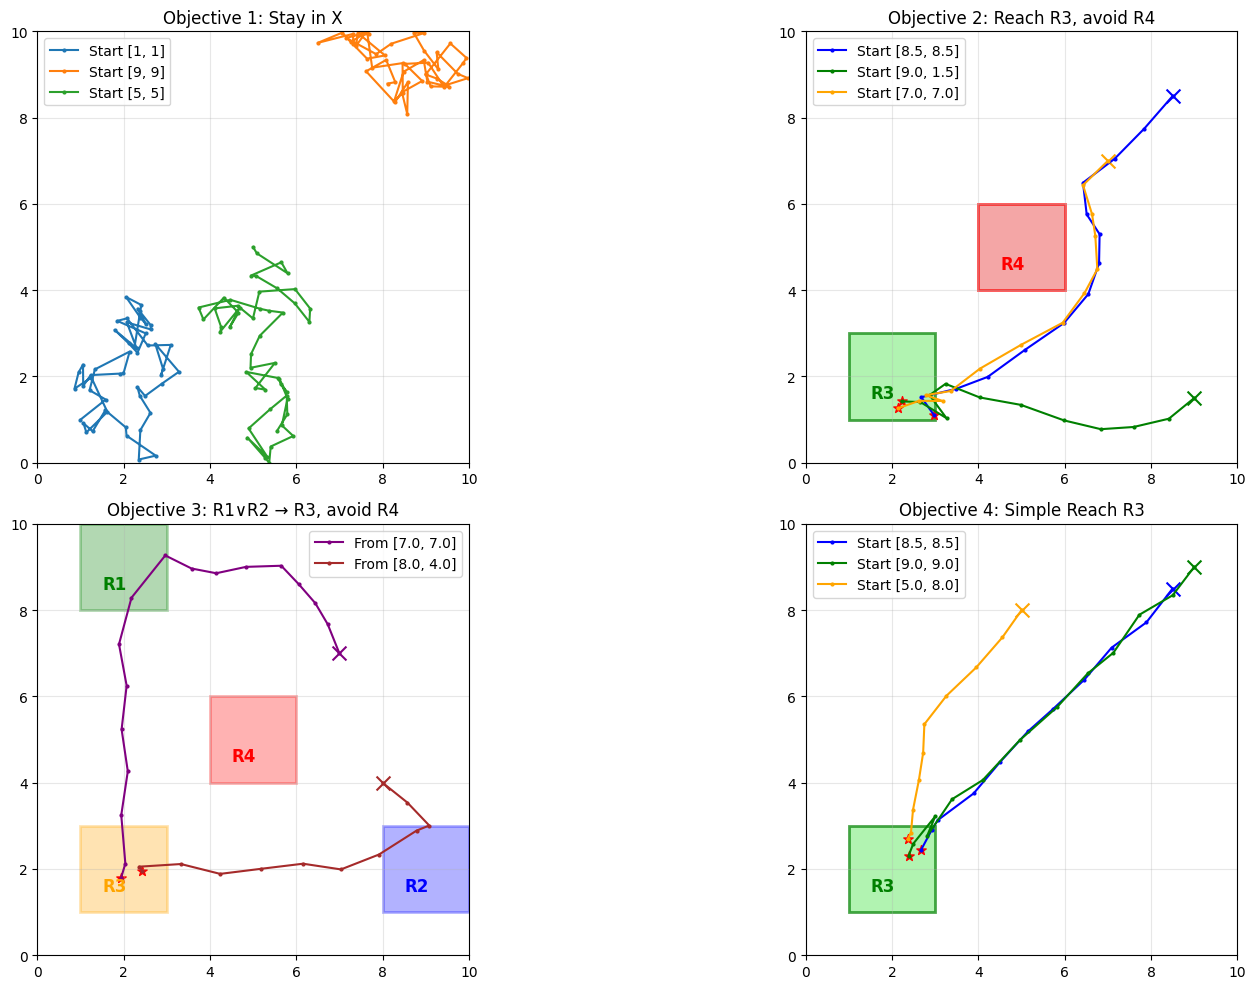

In [ ]:
import numpy as np
import itertools
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helpers
# =========================================================

def interval_to_arrays(interval):
    low = np.array([interval[0][0], interval[1][0]], dtype=float)
    high = np.array([interval[0][1], interval[1][1]], dtype=float)
    return low, high

def transitions_to_dict(transitions):
    td = defaultdict(list)
    for state, control, successors in transitions:
        td[state].append((control, successors))
    return dict(td)

# =========================================================
# 1) 2D Robot abstraction (Point Mass Model)
# =========================================================

class RobotAbstraction:
    def __init__(self, state_intervals, control_values, perturbation, delta_t,
                 discrete_x_y=30, v_vals=5):
        self.state_intervals = state_intervals
        self.control_values = control_values
        self.perturbation = perturbation
        self.delta_t = delta_t
        self.discrete_x_y = discrete_x_y
        self.v_vals = v_vals

        self.state_edges = []
        self.state_to_index = {}
        self.index_to_intervals = {}
        self.cell_centers = []

        self._create_state_mapping()

    def _create_state_mapping(self):
        self.state_edges = [
            np.linspace(self.state_intervals[0][0], self.state_intervals[0][1], self.discrete_x_y + 1),
            np.linspace(self.state_intervals[1][0], self.state_intervals[1][1], self.discrete_x_y + 1)
        ]

        idx = 1
        for i in range(self.discrete_x_y):
            for j in range(self.discrete_x_y):
                x_low, x_high = self.state_edges[0][i], self.state_edges[0][i+1]
                y_low, y_high = self.state_edges[1][j], self.state_edges[1][j+1]
                center = (0.5*(x_low + x_high), 0.5*(y_low + y_high))

                self.cell_centers.append(center)
                self.state_to_index[(i+1, j+1)] = idx
                self.index_to_intervals[idx] = [(x_low, x_high), (y_low, y_high)]
                idx += 1

    def dynamics(self, x, v, w):
        x = np.array(x, dtype=float)
        v = np.array(v, dtype=float)
        w = np.array(w, dtype=float)
        x_next = x + self.delta_t * (v + w)
        x_next[0] = np.clip(x_next[0], self.state_intervals[0][0], self.state_intervals[0][1])
        x_next[1] = np.clip(x_next[1], self.state_intervals[1][0], self.state_intervals[1][1])
        return x_next

    def monotone_overapprox(self, x_min, x_max, v):
        w_min = np.array([self.perturbation[0][0], self.perturbation[1][0]])
        w_max = np.array([self.perturbation[0][1], self.perturbation[1][1]])

        state_corners = [
            np.array([x_min[0], x_min[1]]),
            np.array([x_min[0], x_max[1]]),
            np.array([x_max[0], x_min[1]]),
            np.array([x_max[0], x_max[1]])
        ]
        pert_corners = [
            np.array([w_min[0], w_min[1]]),
            np.array([w_min[0], w_max[1]]),
            np.array([w_max[0], w_min[1]]),
            np.array([w_max[0], w_max[1]])
        ]

        results = []
        for s in state_corners:
            for w in pert_corners:
                res = self.dynamics(s, v, w)
                results.append(res)
        results = np.array(results)
        next_min = results.min(axis=0)
        next_max = results.max(axis=0)

        next_min[0] = max(next_min[0], self.state_intervals[0][0])
        next_min[1] = max(next_min[1], self.state_intervals[1][0])
        next_max[0] = min(next_max[0], self.state_intervals[0][1])
        next_max[1] = min(next_max[1], self.state_intervals[1][1])

        return next_min, next_max

    def _find_state(self, x):
        i = np.digitize(x[0], self.state_edges[0]) - 1
        j = np.digitize(x[1], self.state_edges[1]) - 1
        if 0 <= i < self.discrete_x_y and 0 <= j < self.discrete_x_y:
            return self.state_to_index.get((i+1, j+1), -1)
        return -1

    def compute_transitions(self):
        transitions = []
        vx_vals = np.linspace(self.control_values[0][0], self.control_values[0][1], self.v_vals)
        vy_vals = np.linspace(self.control_values[1][0], self.control_values[1][1], self.v_vals)
        control_grid = list(itertools.product(vx_vals, vy_vals))

        for idx, center in enumerate(self.cell_centers, start=1):
            interval = self.index_to_intervals[idx]
            x_min, x_max = interval_to_arrays(interval)

            for control in control_grid:
                next_min, next_max = self.monotone_overapprox(x_min, x_max, control)
                successors = set()
                xs = np.linspace(next_min[0], next_max[0], 5)
                ys = np.linspace(next_min[1], next_max[1], 5)
                for px, py in itertools.product(xs, ys):
                    s_idx = self._find_state((px, py))
                    if s_idx != -1:
                        successors.add(s_idx)
                transitions.append((idx, control, successors))
        return transitions

    def find_indices_for_interval(self, region):
        indices = []
        for idx, interval in self.index_to_intervals.items():
            overlap = True
            for dim in range(2):
                if not (region[dim][1] >= interval[dim][0] and region[dim][0] <= interval[dim][1]):
                    overlap = False
                    break
            if overlap:
                indices.append(idx)
        return indices

# =========================================================
# 2) Symbolic Synthesis Tools
# =========================================================

class SafetySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ and succ.issubset(R):
                pre_set.add(s)
        return pre_set

    def synthesize(self, safe_set):
        R = set(safe_set)
        while True:
            R_new = R & self.pre(R)
            if R_new == R:
                break
            R = R_new
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and succ and succ.issubset(R):
                controller[s].add(u)
        return R, dict(controller)

class ReachabilitySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ & R:
                pre_set.add(s)
        return pre_set

    def synthesize(self, target_set, safe_set):
        R = set(target_set) & set(safe_set)
        changed = True
        iterations = 0
        
        while changed and iterations < 1000:
            changed = False
            pre_R = self.pre(R)
            new_states = (pre_R & set(safe_set)) - R
            if new_states:
                R |= new_states
                changed = True
            iterations += 1
            
        print(f"Reachability fixed point reached in {iterations} iterations, |R| = {len(R)}")
        
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and (succ & R) and s in safe_set:
                controller[s].add(u)
                
        return R, dict(controller)

# =========================================================
# 3) Improved Simulation with Path Planning
# =========================================================

def find_symbolic_path(start_state, target_set, transitions_dict, robot, avoid_set=None):
    """BFS to find path avoiding certain states"""
    start_idx = robot._find_state(tuple(start_state))
    if start_idx == -1:
        return None

    if start_idx in target_set:
        return [start_idx]

    queue = deque([start_idx])
    parent = {start_idx: None}
    
    while queue:
        s = queue.popleft()

        if s in target_set:
            path = []
            while s is not None:
                path.append(s)
                s = parent[s]
            return list(reversed(path))

        for control, successors in transitions_dict.get(s, []):
            for succ in successors:
                if succ not in parent:
                    # Skip states in avoid_set if specified
                    if avoid_set and succ in avoid_set:
                        continue
                    parent[succ] = s
                    queue.append(succ)

    return None

def simulate_with_path_planning(initial_state, controller_dict, robot, target_region=None, 
                               avoid_region=None, max_steps=200, disturbance_std=0.03):
    """Improved simulation that ensures entry into target region"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Convert regions to state indices
    target_indices = set(robot.find_indices_for_interval(target_region)) if target_region else set()
    avoid_indices = set(robot.find_indices_for_interval(avoid_region)) if avoid_region else set()
    
    # Find symbolic path once at beginning
    symbolic_path = None
    if target_region:
        symbolic_path = find_symbolic_path(initial_state, target_indices, 
                                         transitions_to_dict(robot.compute_transitions()), 
                                         robot, avoid_indices)
    
    # Track if we're close to target to use different strategy
    close_to_target = False
    steps_in_target = 0
    
    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in controller_dict or not controller_dict[s_idx]:
            break
            
        # IMPROVED TARGET CHECKING: Check if we're in target region
        if target_region and region_contains_point(x, target_region, robot):
            steps_in_target += 1
            if steps_in_target >= 2:  # Require staying in target for a few steps
                print(f"✅ Reached and stayed in target at step {step}")
                break
        else:
            steps_in_target = 0
            
        # Choose control based on path planning
        best_u = None
        best_score = float('inf')
        
        for u in controller_dict[s_idx]:
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            center_next = (next_min + next_max) / 2
            
            score = 0
            
            # Target seeking - IMPROVED: prioritize entering target
            if target_region:
                target_center = np.array([
                    (target_region[0][0] + target_region[0][1]) / 2,
                    (target_region[1][0] + target_region[1][1]) / 2
                ])
                distance_to_target = np.linalg.norm(center_next - target_center)
                
                # Check if this control would move us into target region
                will_enter_target = False
                test_points = [
                    center_next,
                    next_min,
                    next_max,
                    (next_min + next_max) / 2
                ]
                for point in test_points:
                    if (target_region[0][0] <= point[0] <= target_region[0][1] and 
                        target_region[1][0] <= point[1] <= target_region[1][1]):
                        will_enter_target = True
                        break
                
                if will_enter_target:
                    # HEAVY bonus for controls that enter target
                    score -= 100.0
                else:
                    # Normal distance-based scoring
                    score += distance_to_target * 2.0
            
            # Obstacle avoidance (heavier penalty)
            if avoid_region:
                avoid_center = np.array([
                    (avoid_region[0][0] + avoid_region[0][1]) / 2,
                    (avoid_region[1][0] + avoid_region[1][1]) / 2
                ])
                avoid_dist = np.linalg.norm(center_next - avoid_center)
                if avoid_dist < 2.0:  # If too close to obstacle
                    score += 10.0 / (avoid_dist + 0.1)  # Strong repulsion
            
            # Follow symbolic path if available
            if symbolic_path and step < len(symbolic_path):
                target_idx = symbolic_path[min(step + 1, len(symbolic_path) - 1)]
                target_iv = robot.index_to_intervals[target_idx]
                target_cell_center = np.array([
                    (target_iv[0][0] + target_iv[0][1]) / 2,
                    (target_iv[1][0] + target_iv[1][1]) / 2
                ])
                path_score = np.linalg.norm(center_next - target_cell_center)
                score += path_score * 0.5
            
            if score < best_score:
                best_score = score
                best_u = u
                
        if best_u is None:
            best_u = random.choice(list(controller_dict[s_idx]))
            
        # Apply dynamics with bounds enforcement
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Sample within bounds - IMPROVED: bias sampling towards target when close
        if target_region and not region_contains_point(x, target_region, robot):
            # Bias sampling towards target center
            target_center = np.array([
                (target_region[0][0] + target_region[0][1]) / 2,
                (target_region[1][0] + target_region[1][1]) / 2
            ])
            
            # Create bias towards target
            direction_to_target = target_center - (next_min + next_max) / 2
            direction_to_target = direction_to_target / (np.linalg.norm(direction_to_target) + 1e-6)
            
            # Sample with bias towards target
            bias_strength = 0.3
            biased_center = (next_min + next_max) / 2 + direction_to_target * bias_strength
            
            # Sample around biased center
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            # Regular uniform sampling
            x = np.random.uniform(next_min, next_max)
        
        x += np.random.normal(0, disturbance_std, size=2)
        
        # STRICT bounds enforcement
        x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
        x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
        
        traj.append(list(x))
        
    # Final check: did we actually reach the target?
    final_in_target = region_contains_point(traj[-1], target_region, robot) if target_region else False
    if target_region and not final_in_target:
        print(f"⚠️  Stopped near target but didn't enter at step {len(traj)-1}")
        
    return traj

def region_contains_point(point, region, robot):
    """Check if a point is inside a region"""
    return (region[0][0] <= point[0] <= region[0][1] and 
            region[1][0] <= point[1] <= region[1][1])

def simulate_temporal(initial_state, robot, transitions_dict, R1, R2, R3, R4, max_steps=200):
    """Temporal logic simulation with improved target entry"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Define phases based on the automaton
    phase = "q0"
    R1_indices = set(robot.find_indices_for_interval(R1))
    R2_indices = set(robot.find_indices_for_interval(R2))
    R3_indices = set(robot.find_indices_for_interval(R3))
    R4_indices = set(robot.find_indices_for_interval(R4))
    safe_states = set(robot.index_to_intervals.keys()) - R4_indices

    # Build safe controller first
    synth = SafetySynthesizer(robot.compute_transitions())
    safe_set, safe_controller = synth.synthesize(safe_states)

    # Track target visits
    visited_R1 = False
    visited_R2 = False
    visited_R3 = False

    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in safe_controller:
            break

        # Update phase based on current state
        current_in_R1 = region_contains_point(x, R1, robot)
        current_in_R2 = region_contains_point(x, R2, robot) 
        current_in_R3 = region_contains_point(x, R3, robot)
        
        if current_in_R1: visited_R1 = True
        if current_in_R2: visited_R2 = True
        if current_in_R3: visited_R3 = True

        if phase == "q0":
            if current_in_R1:
                phase = "q1"
                print(f"Phase transition: q0 -> q1 at step {step}")
            elif current_in_R2:
                phase = "q2"
                print(f"Phase transition: q0 -> q2 at step {step}")
        elif phase in ["q1", "q2"]:
            if current_in_R3:
                phase = "q3"
                print(f"Phase transition: {phase} -> q3 at step {step}")

        # Select control based on phase
        best_u = None
        best_score = float('inf')
        
        for u in safe_controller[s_idx]:
            # Estimate next state region
            interval = robot.index_to_intervals[s_idx]
            x_min, x_max = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(x_min, x_max, u)
            center_next = (next_min + next_max) / 2

            # Calculate score based on phase
            if phase == "q0":
                # Go to nearest of R1 or R2
                r1_center = np.array([(R1[0][0] + R1[0][1])/2, (R1[1][0] + R1[1][1])/2])
                r2_center = np.array([(R2[0][0] + R2[0][1])/2, (R2[1][0] + R2[1][1])/2])
                d1 = np.linalg.norm(center_next - r1_center)
                d2 = np.linalg.norm(center_next - r2_center)
                score = min(d1, d2)
                
            elif phase == "q1":
                # Go to R3, avoid R2
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Bonus for entering R3
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                # Penalty for entering R2
                if any(robot._find_state(center_next) in R2_indices for _ in range(1)):
                    score += 10.0
                    
            elif phase == "q2":
                # Go to R3, avoid R1
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Bonus for entering R3
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                # Penalty for entering R1
                if any(robot._find_state(center_next) in R1_indices for _ in range(1)):
                    score += 10.0
                    
            else:  # phase == "q3"
                # We've succeeded, just maintain position
                score = 0

            if score < best_score:
                best_score = score
                best_u = u

        if best_u is None:
            best_u = random.choice(list(safe_controller[s_idx]))

        # Apply dynamics with target-biased sampling
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Bias sampling towards target in phase q1 or q2
        if phase in ["q1", "q2"]:
            r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
            direction = r3_center - (next_min + next_max) / 2
            direction = direction / (np.linalg.norm(direction) + 1e-6)
            biased_center = (next_min + next_max) / 2 + direction * 0.4
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            x = np.random.uniform(next_min, next_max)
            
        x += np.random.normal(0, 0.03, size=2)
        x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                    [robot.state_intervals[0][1], robot.state_intervals[1][1]])
        traj.append(list(x))

        # Check for success
        if phase == "q3":
            print(f"✅ Temporal spec satisfied at step {step}")
            break

    return traj, {'final_phase': phase, 'visited_R1': visited_R1, 'visited_R2': visited_R2, 'visited_R3': visited_R3}

# =========================================================
# MAIN - Combined version with fixes
# =========================================================

def main():
    # Parameters for 2D system
    state_intervals = [(0, 10), (0, 10)]
    control_values = [(-1.0, 1.0), (-1.0, 1.0)]
    perturbation = [(-0.05, 0.05), (-0.05, 0.05)]
    delta_t = 0.5

    print("Building abstraction...")
    robot = RobotAbstraction(
        state_intervals, control_values, perturbation, delta_t,
        discrete_x_y=30, v_vals=5
    )
    transitions = robot.compute_transitions()
    transitions_dict = transitions_to_dict(transitions)
    print(f"Abstraction built: {len(robot.index_to_intervals)} states")

    # Define geometric regions 
    R1_geom = [(1, 3), (8, 10)]      # Top-left
    R2_geom = [(8, 10), (1, 3)]      # Bottom-right  
    R3_geom = [(1, 3), (1, 3)]       # Bottom-left
    R4_geom = [(4, 6), (4, 6)]       # Center (obstacle)

    # Convert to sets of state indices
    R1_indices = set(robot.find_indices_for_interval(R1_geom))
    R2_indices = set(robot.find_indices_for_interval(R2_geom))
    R3_indices = set(robot.find_indices_for_interval(R3_geom))
    R4_indices = set(robot.find_indices_for_interval(R4_geom))

    all_states = set(robot.index_to_intervals.keys())

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # ===== Objective 1: Safety in X =====
    safe_set1 = all_states
    synth1 = SafetySynthesizer(transitions)
    R1_star, ctrl1 = synth1.synthesize(safe_set1)
    print(f"Obj1: Safe set size = {len(R1_star)}")

    axs[0, 0].set_title("Objective 1: Stay in X")
    for start in [[1,1], [9,9], [5,5]]:
        traj = []
        x = np.array(start, dtype=float)
        for _ in range(50):
            s_idx = robot._find_state(x)
            if s_idx == -1 or s_idx not in ctrl1 or not ctrl1[s_idx]:
                break
            u = random.choice(list(ctrl1[s_idx]))
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
            x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
            traj.append(list(x))
        arr = np.array(traj)
        axs[0, 0].plot([start[0]] + arr[:,0].tolist(), [start[1]] + arr[:,1].tolist(), 
                       '-o', markersize=2, label=f'Start {start}')
    axs[0, 0].set_xlim(state_intervals[0])
    axs[0, 0].set_ylim(state_intervals[1])
    axs[0, 0].set_aspect('equal')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # ===== Objective 2: Reach R3 while avoiding R4 =====
    safe_set2 = all_states - R4_indices
    synth2 = ReachabilitySynthesizer(transitions)
    R2_reach, ctrl2 = synth2.synthesize(R3_indices, safe_set2)

    starts_obj2 = [[8.5, 8.5], [9.0, 1.5], [7.0, 7.0]]
    colors = ['blue', 'green', 'orange']
    
    axs[0, 1].set_title("Objective 2: Reach R3, avoid R4")
    rect_r3 = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    rect_r4 = patches.Rectangle(
        (R4_geom[0][0], R4_geom[1][0]),
        R4_geom[0][1] - R4_geom[0][0],
        R4_geom[1][1] - R4_geom[1][0],
        linewidth=2, edgecolor='red', facecolor='lightcoral', alpha=0.7
    )
    axs[0, 1].add_patch(rect_r3)
    axs[0, 1].add_patch(rect_r4)
    axs[0, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    axs[0, 1].text(R4_geom[0][0] + 0.5, R4_geom[1][0] + 0.5, 'R4', color='red', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj2):
        if robot._find_state(start) in R2_reach:
            traj = simulate_with_path_planning(start, ctrl2, robot, target_region=R3_geom, avoid_region=R4_geom)
            arr = np.array(traj)
            axs[0, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors[i], label=f'Start {start}')
            axs[0, 1].scatter(start[0], start[1], c=colors[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"✅ Trajectory from {start} reached R3")
                axs[0, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"❌ Trajectory from {start} did not reach R3 (stopped at {traj[-1]})")
        else:
            print(f"⚠️  Start {start} not in reachable set")
    
    axs[0, 1].set_xlim(state_intervals[0])
    axs[0, 1].set_ylim(state_intervals[1])
    axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # ===== Objective 3: Temporal logic =====
    start3a = [7.0, 7.0]
    start3b = [8.0, 4.0]

    axs[1, 0].set_title("Objective 3: R1∨R2 → R3, avoid R4")
    for geom, color, label in [(R1_geom, 'green', 'R1'), (R2_geom, 'blue', 'R2'), 
                              (R3_geom, 'orange', 'R3'), (R4_geom, 'red', 'R4')]:
        rect = patches.Rectangle(
            (geom[0][0], geom[1][0]),
            geom[0][1] - geom[0][0],
            geom[1][1] - geom[1][0],
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.3
        )
        axs[1, 0].add_patch(rect)
        axs[1, 0].text(geom[0][0] + 0.5, geom[1][0] + 0.5, label, color=color, 
                       fontsize=12, fontweight='bold')
    
    traj3a, info3a = simulate_temporal(start3a, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    traj3b, info3b = simulate_temporal(start3b, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    
    for traj, start, col in [(traj3a, start3a, 'purple'), (traj3b, start3b, 'brown')]:
        arr = np.array(traj)
        axs[1, 0].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=col, label=f'From {start}')
        axs[1, 0].scatter(start[0], start[1], c=col, s=100, marker='x')
        # Mark final position if in R3
        if region_contains_point(traj[-1], R3_geom, robot):
            axs[1, 0].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
    
    axs[1, 0].set_xlim(state_intervals[0])
    axs[1, 0].set_ylim(state_intervals[1])
    axs[1, 0].set_aspect('equal')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].legend()

    # ===== Objective 4: Simple Reachability =====
    synth4 = ReachabilitySynthesizer(transitions)
    R4_reach, ctrl4 = synth4.synthesize(R3_indices, all_states)

    starts_obj4 = [[8.5, 8.5], [9.0, 9.0], [5.0, 8.0]]
    colors_obj4 = ['blue', 'green', 'orange']
    
    axs[1, 1].set_title("Objective 4: Simple Reach R3")
    rect_r3_simple = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    axs[1, 1].add_patch(rect_r3_simple)
    axs[1, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj4):
        if robot._find_state(start) in R4_reach:
            traj = simulate_with_path_planning(start, ctrl4, robot, target_region=R3_geom)
            arr = np.array(traj)
            axs[1, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors_obj4[i], label=f'Start {start}')
            axs[1, 1].scatter(start[0], start[1], c=colors_obj4[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"✅ Simple reach from {start} succeeded")
                axs[1, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"❌ Simple reach from {start} failed (stopped at {traj[-1]})")
        else:
            print(f"⚠️  Start {start} not in simple reachable set")
    
    axs[1, 1].set_xlim(state_intervals[0])
    axs[1, 1].set_ylim(state_intervals[1])
    axs[1, 1].set_aspect('equal')
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Building abstraction...
Abstraction built: 900 states
Obj1: Safe set size = 900
Reachability fixed point reached in 15 iterations, |R| = 836
✅ Reached and stayed in target at step 15
✅ Trajectory from [8.5, 8.5] reached R3
✅ Reached and stayed in target at step 11
✅ Trajectory from [9.0, 1.5] reached R3
✅ Reached and stayed in target at step 12
✅ Trajectory from [7.0, 7.0] reached R3
Phase transition: q0 -> q1 at step 8
Phase transition: q3 -> q3 at step 15
✅ Temporal spec satisfied at step 15
Phase transition: q0 -> q2 at step 3
Phase transition: q3 -> q3 at step 10
✅ Temporal spec satisfied at step 10
Reachability fixed point reached in 11 iterations, |R| = 900
✅ Reached and stayed in target at step 10
✅ Simple reach from [8.5, 8.5] succeeded
✅ Reached and stayed in target at step 11
✅ Simple reach from [9.0, 9.0] succeeded
✅ Reached and stayed in target at step 9
✅ Simple reach from [5.0, 8.0] succeeded
Reachability fixed point reached in 16 iterations, |R| = 735
Reachability fixed 

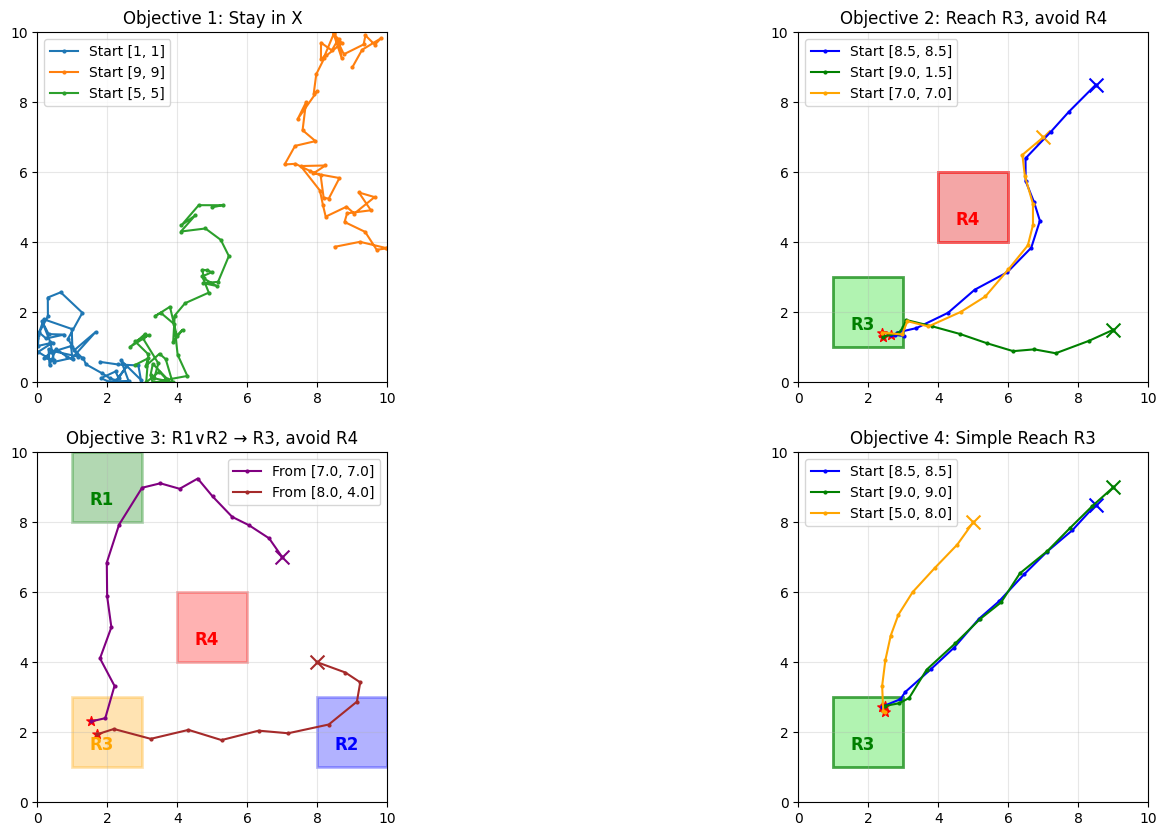

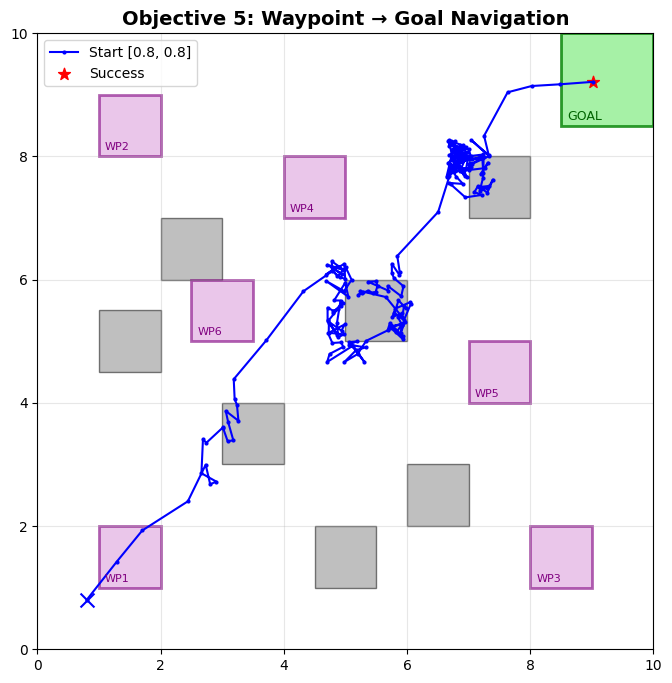

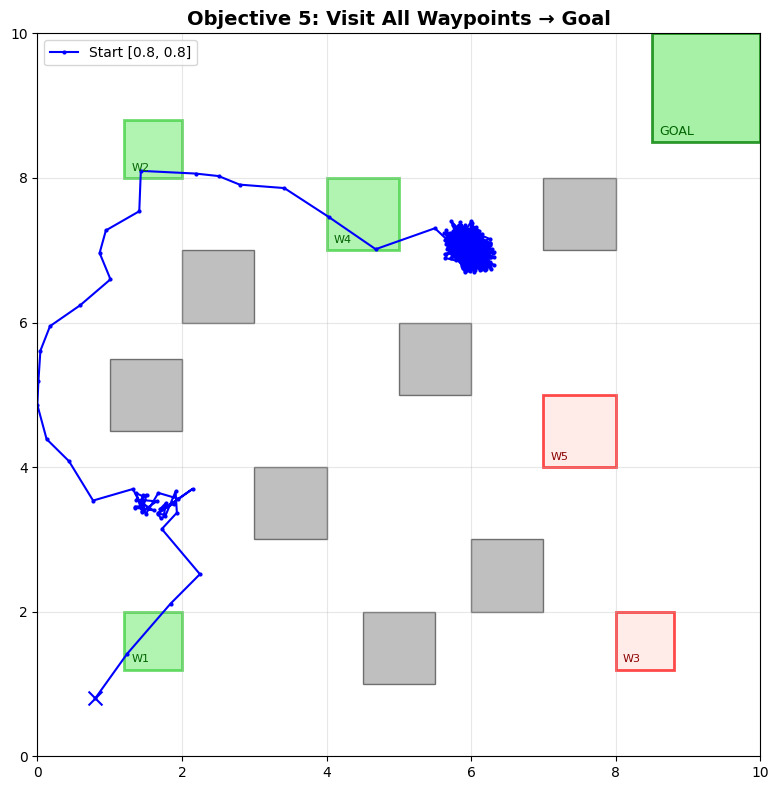

In [10]:
import numpy as np
import itertools
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helpers
# =========================================================

def interval_to_arrays(interval):
    low = np.array([interval[0][0], interval[1][0]], dtype=float)
    high = np.array([interval[0][1], interval[1][1]], dtype=float)
    return low, high

def transitions_to_dict(transitions):
    td = defaultdict(list)
    for state, control, successors in transitions:
        td[state].append((control, successors))
    return dict(td)

# =========================================================
# 1) 2D Robot abstraction (Point Mass Model)
# =========================================================

class RobotAbstraction:
    def __init__(self, state_intervals, control_values, perturbation, delta_t,
                 discrete_x_y=30, v_vals=5):
        self.state_intervals = state_intervals
        self.control_values = control_values
        self.perturbation = perturbation
        self.delta_t = delta_t
        self.discrete_x_y = discrete_x_y
        self.v_vals = v_vals

        self.state_edges = []
        self.state_to_index = {}
        self.index_to_intervals = {}
        self.cell_centers = []

        self._create_state_mapping()

    def _create_state_mapping(self):
        self.state_edges = [
            np.linspace(self.state_intervals[0][0], self.state_intervals[0][1], self.discrete_x_y + 1),
            np.linspace(self.state_intervals[1][0], self.state_intervals[1][1], self.discrete_x_y + 1)
        ]

        idx = 1
        for i in range(self.discrete_x_y):
            for j in range(self.discrete_x_y):
                x_low, x_high = self.state_edges[0][i], self.state_edges[0][i+1]
                y_low, y_high = self.state_edges[1][j], self.state_edges[1][j+1]
                center = (0.5*(x_low + x_high), 0.5*(y_low + y_high))

                self.cell_centers.append(center)
                self.state_to_index[(i+1, j+1)] = idx
                self.index_to_intervals[idx] = [(x_low, x_high), (y_low, y_high)]
                idx += 1

    def dynamics(self, x, v, w):
        x = np.array(x, dtype=float)
        v = np.array(v, dtype=float)
        w = np.array(w, dtype=float)
        x_next = x + self.delta_t * (v + w)
        x_next[0] = np.clip(x_next[0], self.state_intervals[0][0], self.state_intervals[0][1])
        x_next[1] = np.clip(x_next[1], self.state_intervals[1][0], self.state_intervals[1][1])
        return x_next

    def monotone_overapprox(self, x_min, x_max, v):
        w_min = np.array([self.perturbation[0][0], self.perturbation[1][0]])
        w_max = np.array([self.perturbation[0][1], self.perturbation[1][1]])

        state_corners = [
            np.array([x_min[0], x_min[1]]),
            np.array([x_min[0], x_max[1]]),
            np.array([x_max[0], x_min[1]]),
            np.array([x_max[0], x_max[1]])
        ]
        pert_corners = [
            np.array([w_min[0], w_min[1]]),
            np.array([w_min[0], w_max[1]]),
            np.array([w_max[0], w_min[1]]),
            np.array([w_max[0], w_max[1]])
        ]

        results = []
        for s in state_corners:
            for w in pert_corners:
                res = self.dynamics(s, v, w)
                results.append(res)
        results = np.array(results)
        next_min = results.min(axis=0)
        next_max = results.max(axis=0)

        next_min[0] = max(next_min[0], self.state_intervals[0][0])
        next_min[1] = max(next_min[1], self.state_intervals[1][0])
        next_max[0] = min(next_max[0], self.state_intervals[0][1])
        next_max[1] = min(next_max[1], self.state_intervals[1][1])

        return next_min, next_max

    def _find_state(self, x):
        i = np.digitize(x[0], self.state_edges[0]) - 1
        j = np.digitize(x[1], self.state_edges[1]) - 1
        if 0 <= i < self.discrete_x_y and 0 <= j < self.discrete_x_y:
            return self.state_to_index.get((i+1, j+1), -1)
        return -1

    def compute_transitions(self):
        transitions = []
        vx_vals = np.linspace(self.control_values[0][0], self.control_values[0][1], self.v_vals)
        vy_vals = np.linspace(self.control_values[1][0], self.control_values[1][1], self.v_vals)
        control_grid = list(itertools.product(vx_vals, vy_vals))

        for idx, center in enumerate(self.cell_centers, start=1):
            interval = self.index_to_intervals[idx]
            x_min, x_max = interval_to_arrays(interval)

            for control in control_grid:
                next_min, next_max = self.monotone_overapprox(x_min, x_max, control)
                successors = set()
                xs = np.linspace(next_min[0], next_max[0], 5)
                ys = np.linspace(next_min[1], next_max[1], 5)
                for px, py in itertools.product(xs, ys):
                    s_idx = self._find_state((px, py))
                    if s_idx != -1:
                        successors.add(s_idx)
                transitions.append((idx, control, successors))
        return transitions

    def find_indices_for_interval(self, region):
        indices = []
        for idx, interval in self.index_to_intervals.items():
            overlap = True
            for dim in range(2):
                if not (region[dim][1] >= interval[dim][0] and region[dim][0] <= interval[dim][1]):
                    overlap = False
                    break
            if overlap:
                indices.append(idx)
        return indices

# =========================================================
# 2) Symbolic Synthesis Tools
# =========================================================

class SafetySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ and succ.issubset(R):
                pre_set.add(s)
        return pre_set

    def synthesize(self, safe_set):
        R = set(safe_set)
        while True:
            R_new = R & self.pre(R)
            if R_new == R:
                break
            R = R_new
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and succ and succ.issubset(R):
                controller[s].add(u)
        return R, dict(controller)

class ReachabilitySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ & R:
                pre_set.add(s)
        return pre_set

    def synthesize(self, target_set, safe_set):
        R = set(target_set) & set(safe_set)
        changed = True
        iterations = 0
        
        while changed and iterations < 1000:
            changed = False
            pre_R = self.pre(R)
            new_states = (pre_R & set(safe_set)) - R
            if new_states:
                R |= new_states
                changed = True
            iterations += 1
            
        print(f"Reachability fixed point reached in {iterations} iterations, |R| = {len(R)}")
        
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and (succ & R) and s in safe_set:
                controller[s].add(u)
                
        return R, dict(controller)

# =========================================================
# 3) Improved Simulation with Path Planning
# =========================================================

def find_symbolic_path(start_state, target_set, transitions_dict, robot, avoid_set=None):
    """BFS to find path avoiding certain states"""
    start_idx = robot._find_state(tuple(start_state))
    if start_idx == -1:
        return None

    if start_idx in target_set:
        return [start_idx]

    queue = deque([start_idx])
    parent = {start_idx: None}
    
    while queue:
        s = queue.popleft()

        if s in target_set:
            path = []
            while s is not None:
                path.append(s)
                s = parent[s]
            return list(reversed(path))

        for control, successors in transitions_dict.get(s, []):
            for succ in successors:
                if succ not in parent:
                    # Skip states in avoid_set if specified
                    if avoid_set and succ in avoid_set:
                        continue
                    parent[succ] = s
                    queue.append(succ)

    return None

def simulate_with_path_planning(initial_state, controller_dict, robot, target_region=None, 
                               avoid_region=None, max_steps=200, disturbance_std=0.03):
    """Improved simulation that ensures entry into target region"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Convert regions to state indices
    target_indices = set(robot.find_indices_for_interval(target_region)) if target_region else set()
    avoid_indices = set(robot.find_indices_for_interval(avoid_region)) if avoid_region else set()
    
    # Find symbolic path once at beginning
    symbolic_path = None
    if target_region:
        symbolic_path = find_symbolic_path(initial_state, target_indices, 
                                         transitions_to_dict(robot.compute_transitions()), 
                                         robot, avoid_indices)
    
    # Track if we're close to target to use different strategy
    close_to_target = False
    steps_in_target = 0
    
    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in controller_dict or not controller_dict[s_idx]:
            break
            
        # IMPROVED TARGET CHECKING: Check if we're in target region
        if target_region and region_contains_point(x, target_region, robot):
            steps_in_target += 1
            if steps_in_target >= 2:  # Require staying in target for a few steps
                print(f"✅ Reached and stayed in target at step {step}")
                break
        else:
            steps_in_target = 0
            
        # Choose control based on path planning
        best_u = None
        best_score = float('inf')
        
        for u in controller_dict[s_idx]:
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            center_next = (next_min + next_max) / 2
            
            score = 0
            
            # Target seeking - IMPROVED: prioritize entering target
            if target_region:
                target_center = np.array([
                    (target_region[0][0] + target_region[0][1]) / 2,
                    (target_region[1][0] + target_region[1][1]) / 2
                ])
                distance_to_target = np.linalg.norm(center_next - target_center)
                
                # Check if this control would move us into target region
                will_enter_target = False
                test_points = [
                    center_next,
                    next_min,
                    next_max,
                    (next_min + next_max) / 2
                ]
                for point in test_points:
                    if (target_region[0][0] <= point[0] <= target_region[0][1] and 
                        target_region[1][0] <= point[1] <= target_region[1][1]):
                        will_enter_target = True
                        break
                
                if will_enter_target:
                    # HEAVY bonus for controls that enter target
                    score -= 100.0
                else:
                    # Normal distance-based scoring
                    score += distance_to_target * 2.0
            
            # Obstacle avoidance (heavier penalty)
            if avoid_region:
                avoid_center = np.array([
                    (avoid_region[0][0] + avoid_region[0][1]) / 2,
                    (avoid_region[1][0] + avoid_region[1][1]) / 2
                ])
                avoid_dist = np.linalg.norm(center_next - avoid_center)
                if avoid_dist < 2.0:  # If too close to obstacle
                    score += 10.0 / (avoid_dist + 0.1)  # Strong repulsion
            
            # Follow symbolic path if available
            if symbolic_path and step < len(symbolic_path):
                target_idx = symbolic_path[min(step + 1, len(symbolic_path) - 1)]
                target_iv = robot.index_to_intervals[target_idx]
                target_cell_center = np.array([
                    (target_iv[0][0] + target_iv[0][1]) / 2,
                    (target_iv[1][0] + target_iv[1][1]) / 2
                ])
                path_score = np.linalg.norm(center_next - target_cell_center)
                score += path_score * 0.5
            
            if score < best_score:
                best_score = score
                best_u = u
                
        if best_u is None:
            best_u = random.choice(list(controller_dict[s_idx]))
            
        # Apply dynamics with bounds enforcement
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Sample within bounds - IMPROVED: bias sampling towards target when close
        if target_region and not region_contains_point(x, target_region, robot):
            # Bias sampling towards target center
            target_center = np.array([
                (target_region[0][0] + target_region[0][1]) / 2,
                (target_region[1][0] + target_region[1][1]) / 2
            ])
            
            # Create bias towards target
            direction_to_target = target_center - (next_min + next_max) / 2
            direction_to_target = direction_to_target / (np.linalg.norm(direction_to_target) + 1e-6)
            
            # Sample with bias towards target
            bias_strength = 0.3
            biased_center = (next_min + next_max) / 2 + direction_to_target * bias_strength
            
            # Sample around biased center
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            # Regular uniform sampling
            x = np.random.uniform(next_min, next_max)
        
        x += np.random.normal(0, disturbance_std, size=2)
        
        # STRICT bounds enforcement
        x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
        x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
        
        traj.append(list(x))
        
    # Final check: did we actually reach the target?
    final_in_target = region_contains_point(traj[-1], target_region, robot) if target_region else False
    if target_region and not final_in_target:
        print(f"⚠️  Stopped near target but didn't enter at step {len(traj)-1}")
        
    return traj

def region_contains_point(point, region, robot):
    """Check if a point is inside a region"""
    return (region[0][0] <= point[0] <= region[0][1] and 
            region[1][0] <= point[1] <= region[1][1])

def simulate_temporal(initial_state, robot, transitions_dict, R1, R2, R3, R4, max_steps=200):
    """Temporal logic simulation with improved target entry"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Define phases based on the automaton
    phase = "q0"
    R1_indices = set(robot.find_indices_for_interval(R1))
    R2_indices = set(robot.find_indices_for_interval(R2))
    R3_indices = set(robot.find_indices_for_interval(R3))
    R4_indices = set(robot.find_indices_for_interval(R4))
    safe_states = set(robot.index_to_intervals.keys()) - R4_indices

    # Build safe controller first
    synth = SafetySynthesizer(robot.compute_transitions())
    safe_set, safe_controller = synth.synthesize(safe_states)

    # Track target visits
    visited_R1 = False
    visited_R2 = False
    visited_R3 = False

    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in safe_controller:
            break

        # Update phase based on current state
        current_in_R1 = region_contains_point(x, R1, robot)
        current_in_R2 = region_contains_point(x, R2, robot) 
        current_in_R3 = region_contains_point(x, R3, robot)
        
        if current_in_R1: visited_R1 = True
        if current_in_R2: visited_R2 = True
        if current_in_R3: visited_R3 = True

        if phase == "q0":
            if current_in_R1:
                phase = "q1"
                print(f"Phase transition: q0 -> q1 at step {step}")
            elif current_in_R2:
                phase = "q2"
                print(f"Phase transition: q0 -> q2 at step {step}")
        elif phase in ["q1", "q2"]:
            if current_in_R3:
                phase = "q3"
                print(f"Phase transition: {phase} -> q3 at step {step}")

        # Select control based on phase
        best_u = None
        best_score = float('inf')
        
        for u in safe_controller[s_idx]:
            # Estimate next state region
            interval = robot.index_to_intervals[s_idx]
            x_min, x_max = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(x_min, x_max, u)
            center_next = (next_min + next_max) / 2

            # Calculate score based on phase
            if phase == "q0":
                # Go to nearest of R1 or R2
                r1_center = np.array([(R1[0][0] + R1[0][1])/2, (R1[1][0] + R1[1][1])/2])
                r2_center = np.array([(R2[0][0] + R2[0][1])/2, (R2[1][0] + R2[1][1])/2])
                d1 = np.linalg.norm(center_next - r1_center)
                d2 = np.linalg.norm(center_next - r2_center)
                score = min(d1, d2)
                
            elif phase == "q1":
                # Go to R3, avoid R2
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Bonus for entering R3
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                # Penalty for entering R2
                if any(robot._find_state(center_next) in R2_indices for _ in range(1)):
                    score += 10.0
                    
            elif phase == "q2":
                # Go to R3, avoid R1
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Bonus for entering R3
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                # Penalty for entering R1
                if any(robot._find_state(center_next) in R1_indices for _ in range(1)):
                    score += 10.0
                    
            else:  # phase == "q3"
                # We've succeeded, just maintain position
                score = 0

            if score < best_score:
                best_score = score
                best_u = u

        if best_u is None:
            best_u = random.choice(list(safe_controller[s_idx]))

        # Apply dynamics with target-biased sampling
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Bias sampling towards target in phase q1 or q2
        if phase in ["q1", "q2"]:
            r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
            direction = r3_center - (next_min + next_max) / 2
            direction = direction / (np.linalg.norm(direction) + 1e-6)
            biased_center = (next_min + next_max) / 2 + direction * 0.4
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            x = np.random.uniform(next_min, next_max)
            
        x += np.random.normal(0, 0.03, size=2)
        x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                    [robot.state_intervals[0][1], robot.state_intervals[1][1]])
        traj.append(list(x))

        # Check for success
        if phase == "q3":
            print(f"✅ Temporal spec satisfied at step {step}")
            break

    return traj, {'final_phase': phase, 'visited_R1': visited_R1, 'visited_R2': visited_R2, 'visited_R3': visited_R3}

# =========================================================
# MAIN - Combined version with fixes
# =========================================================

def main():
    # Parameters for 2D system
    state_intervals = [(0, 10), (0, 10)]
    control_values = [(-1.0, 1.0), (-1.0, 1.0)]
    perturbation = [(-0.05, 0.05), (-0.05, 0.05)]
    delta_t = 0.5

    print("Building abstraction...")
    robot = RobotAbstraction(
        state_intervals, control_values, perturbation, delta_t,
        discrete_x_y=30, v_vals=5
    )
    transitions = robot.compute_transitions()
    transitions_dict = transitions_to_dict(transitions)
    print(f"Abstraction built: {len(robot.index_to_intervals)} states")

    # Define geometric regions 
    R1_geom = [(1, 3), (8, 10)]      # Top-left
    R2_geom = [(8, 10), (1, 3)]      # Bottom-right  
    R3_geom = [(1, 3), (1, 3)]       # Bottom-left
    R4_geom = [(4, 6), (4, 6)]       # Center (obstacle)

    # Convert to sets of state indices
    R1_indices = set(robot.find_indices_for_interval(R1_geom))
    R2_indices = set(robot.find_indices_for_interval(R2_geom))
    R3_indices = set(robot.find_indices_for_interval(R3_geom))
    R4_indices = set(robot.find_indices_for_interval(R4_geom))

    all_states = set(robot.index_to_intervals.keys())

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # ===== Objective 1: Safety in X =====
    safe_set1 = all_states
    synth1 = SafetySynthesizer(transitions)
    R1_star, ctrl1 = synth1.synthesize(safe_set1)
    print(f"Obj1: Safe set size = {len(R1_star)}")

    axs[0, 0].set_title("Objective 1: Stay in X")
    for start in [[1,1], [9,9], [5,5]]:
        traj = []
        x = np.array(start, dtype=float)
        for _ in range(50):
            s_idx = robot._find_state(x)
            if s_idx == -1 or s_idx not in ctrl1 or not ctrl1[s_idx]:
                break
            u = random.choice(list(ctrl1[s_idx]))
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
            x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
            traj.append(list(x))
        arr = np.array(traj)
        axs[0, 0].plot([start[0]] + arr[:,0].tolist(), [start[1]] + arr[:,1].tolist(), 
                       '-o', markersize=2, label=f'Start {start}')
    axs[0, 0].set_xlim(state_intervals[0])
    axs[0, 0].set_ylim(state_intervals[1])
    axs[0, 0].set_aspect('equal')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # ===== Objective 2: Reach R3 while avoiding R4 =====
    safe_set2 = all_states - R4_indices
    synth2 = ReachabilitySynthesizer(transitions)
    R2_reach, ctrl2 = synth2.synthesize(R3_indices, safe_set2)

    starts_obj2 = [[8.5, 8.5], [9.0, 1.5], [7.0, 7.0]]
    colors = ['blue', 'green', 'orange']
    
    axs[0, 1].set_title("Objective 2: Reach R3, avoid R4")
    rect_r3 = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    rect_r4 = patches.Rectangle(
        (R4_geom[0][0], R4_geom[1][0]),
        R4_geom[0][1] - R4_geom[0][0],
        R4_geom[1][1] - R4_geom[1][0],
        linewidth=2, edgecolor='red', facecolor='lightcoral', alpha=0.7
    )
    axs[0, 1].add_patch(rect_r3)
    axs[0, 1].add_patch(rect_r4)
    axs[0, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    axs[0, 1].text(R4_geom[0][0] + 0.5, R4_geom[1][0] + 0.5, 'R4', color='red', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj2):
        if robot._find_state(start) in R2_reach:
            traj = simulate_with_path_planning(start, ctrl2, robot, target_region=R3_geom, avoid_region=R4_geom)
            arr = np.array(traj)
            axs[0, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors[i], label=f'Start {start}')
            axs[0, 1].scatter(start[0], start[1], c=colors[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"✅ Trajectory from {start} reached R3")
                axs[0, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"❌ Trajectory from {start} did not reach R3 (stopped at {traj[-1]})")
        else:
            print(f"⚠️  Start {start} not in reachable set")
    
    axs[0, 1].set_xlim(state_intervals[0])
    axs[0, 1].set_ylim(state_intervals[1])
    axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # ===== Objective 3: Temporal logic =====
    start3a = [7.0, 7.0]
    start3b = [8.0, 4.0]

    axs[1, 0].set_title("Objective 3: R1∨R2 → R3, avoid R4")
    for geom, color, label in [(R1_geom, 'green', 'R1'), (R2_geom, 'blue', 'R2'), 
                              (R3_geom, 'orange', 'R3'), (R4_geom, 'red', 'R4')]:
        rect = patches.Rectangle(
            (geom[0][0], geom[1][0]),
            geom[0][1] - geom[0][0],
            geom[1][1] - geom[1][0],
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.3
        )
        axs[1, 0].add_patch(rect)
        axs[1, 0].text(geom[0][0] + 0.5, geom[1][0] + 0.5, label, color=color, 
                       fontsize=12, fontweight='bold')
    
    traj3a, info3a = simulate_temporal(start3a, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    traj3b, info3b = simulate_temporal(start3b, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    
    for traj, start, col in [(traj3a, start3a, 'purple'), (traj3b, start3b, 'brown')]:
        arr = np.array(traj)
        axs[1, 0].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=col, label=f'From {start}')
        axs[1, 0].scatter(start[0], start[1], c=col, s=100, marker='x')
        # Mark final position if in R3
        if region_contains_point(traj[-1], R3_geom, robot):
            axs[1, 0].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
    
    axs[1, 0].set_xlim(state_intervals[0])
    axs[1, 0].set_ylim(state_intervals[1])
    axs[1, 0].set_aspect('equal')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].legend()

    # ===== Objective 4: Simple Reachability =====
    synth4 = ReachabilitySynthesizer(transitions)
    R4_reach, ctrl4 = synth4.synthesize(R3_indices, all_states)

    starts_obj4 = [[8.5, 8.5], [9.0, 9.0], [5.0, 8.0]]
    colors_obj4 = ['blue', 'green', 'orange']
    
    axs[1, 1].set_title("Objective 4: Simple Reach R3")
    rect_r3_simple = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    axs[1, 1].add_patch(rect_r3_simple)
    axs[1, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj4):
        if robot._find_state(start) in R4_reach:
            traj = simulate_with_path_planning(start, ctrl4, robot, target_region=R3_geom)
            arr = np.array(traj)
            axs[1, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors_obj4[i], label=f'Start {start}')
            axs[1, 1].scatter(start[0], start[1], c=colors_obj4[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"✅ Simple reach from {start} succeeded")
                axs[1, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"❌ Simple reach from {start} failed (stopped at {traj[-1]})")
        else:
            print(f"⚠️  Start {start} not in simple reachable set")
    
    axs[1, 1].set_xlim(state_intervals[0])
    axs[1, 1].set_ylim(state_intervals[1])
    axs[1, 1].set_aspect('equal')
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].legend()
        # ===== Objective 5: Multi-Waypoint Navigation to Fixed Goal =====
    # Define fixed goal region (top-right)
    GOAL_REGION = [(8.5, 10.0), (8.5, 10.0)]

    # Define multiple intermediate waypoints (stops)
    WAYPOINTS = [
        [(1.0, 2.0), (1.0, 2.0)],   # Bottom-left
        [(1.0, 2.0), (8.0, 9.0)],   # Top-left
        [(8.0, 9.0), (1.0, 2.0)],   # Bottom-right
        [(4.0, 5.0), (7.0, 8.0)],   # Left-center
        [(7.0, 8.0), (4.0, 5.0)],   # Bottom-center
        [(2.5, 3.5), (5.0, 6.0)],   # Middle-left
    ]

    # Define obstacles
    OBSTACLES = [
        [(3, 4), (3, 4)],
        [(6, 7), (2, 3)],
        [(2, 3), (6, 7)],
        [(7, 8), (7, 8)],
        [(4.5, 5.5), (1, 2)],
        [(1, 2), (4.5, 5.5)],
        [(5, 6), (5, 6)],  # Center obstacle
    ]

    # Convert to state indices
    goal_indices = set(robot.find_indices_for_interval(GOAL_REGION))
    waypoint_indices_list = [set(robot.find_indices_for_interval(wp)) for wp in WAYPOINTS]
    obstacle_indices = set().union(*[set(robot.find_indices_for_interval(obs)) for obs in OBSTACLES])

    # Safe set = all states minus obstacles
    safe_set5 = all_states - obstacle_indices

    # Synthesize safe controller
    synth_safe = SafetySynthesizer(transitions)
    safe_set_final, safe_controller = synth_safe.synthesize(safe_set5)

    # Synthesize reachability to GOAL
    synth_goal = ReachabilitySynthesizer(transitions)
    goal_reachable, goal_controller = synth_goal.synthesize(goal_indices, safe_set5)

    # Synthesize reachability to each waypoint
    waypoint_reachable_sets = []
    waypoint_controllers = []
    for i, wp_indices in enumerate(waypoint_indices_list):
        synth_wp = ReachabilitySynthesizer(transitions)
        reachable, ctrl = synth_wp.synthesize(wp_indices, safe_set5)
        waypoint_reachable_sets.append(reachable)
        waypoint_controllers.append(ctrl)

    # Choose a start point (you can change this)
    start5 = [0.8, 0.8]  # near bottom-left

    # ----------------------------
    # Simulation Logic
    # ----------------------------
    def simulate_waypoint_to_goal(start, robot, safe_controller, goal_controller, goal_region,
                                  waypoint_controllers, waypoint_geoms, waypoint_reachable_sets,
                                  obstacles, max_steps=400):
        traj = [list(start)]
        x = np.array(start, dtype=float)
        reached_waypoint = False
        reached_goal = False
        current_stage = "waypoint"  # or "goal"

        # Determine best initial waypoint
        s0_idx = robot._find_state(x)
        best_wp_idx = -1
        best_dist = float('inf')
        start_pos = x

        if s0_idx == -1:
            print("⚠️ Start position outside abstraction!")
            return traj, False, False

        for i, (wp_geom, reachable_set) in enumerate(zip(waypoint_geoms, waypoint_reachable_sets)):
            if s0_idx in reachable_set:
                wp_center = np.array([
                    (wp_geom[0][0] + wp_geom[0][1]) / 2,
                    (wp_geom[1][0] + wp_geom[1][1]) / 2
                ])
                dist = np.linalg.norm(start_pos - wp_center)
                if dist < best_dist:
                    best_dist = dist
                    best_wp_idx = i

        if best_wp_idx == -1:
            print("⚠️ No reachable waypoint found! Using safe controller only.")
            target_controller = safe_controller
            target_region = None
            current_stage = "safe_only"
        else:
            print(f"🎯 Selected waypoint {best_wp_idx} (nearest reachable)")
            target_controller = waypoint_controllers[best_wp_idx]
            target_region = waypoint_geoms[best_wp_idx]

        for step in range(max_steps):
            s_idx = robot._find_state(x)
            if s_idx == -1:
                break

            # Check stages
            if current_stage == "waypoint":
                if region_contains_point(x, target_region, robot):
                    print(f"✅ Reached waypoint at step {step}")
                    current_stage = "goal"
                    target_controller = goal_controller
                    target_region = goal_region
            elif current_stage == "goal":
                if region_contains_point(x, goal_region, robot):
                    print(f"✅ Reached final goal at step {step}")
                    reached_goal = True
                    break

            # Choose control
            if s_idx in target_controller and target_controller[s_idx]:
                best_u = None
                best_score = float('inf')
                for u in target_controller[s_idx]:
                    interval = robot.index_to_intervals[s_idx]
                    low, high = interval_to_arrays(interval)
                    next_min, next_max = robot.monotone_overapprox(low, high, u)
                    center_next = (next_min + next_max) / 2

                    score = 0
                    if target_region is not None:
                        target_center = np.array([
                            (target_region[0][0] + target_region[0][1]) / 2,
                            (target_region[1][0] + target_region[1][1]) / 2
                        ])
                        score = np.linalg.norm(center_next - target_center)
                        # Bonus for entering
                        if region_contains_point(center_next, target_region, robot):
                            score -= 50.0
                    if score < best_score:
                        best_score = score
                        best_u = u
                u = best_u if best_u is not None else random.choice(list(target_controller[s_idx]))
            else:
                # Fallback
                if s_idx in safe_controller and safe_controller[s_idx]:
                    u = random.choice(list(safe_controller[s_idx]))
                else:
                    u = (0.0, 0.0)

            # Apply dynamics
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                        [robot.state_intervals[0][1], robot.state_intervals[1][1]])
            traj.append(list(x))

            if step % 100 == 0:
                print(f"Step {step}, stage: {current_stage}")

        final_in_goal = region_contains_point(traj[-1], goal_region, robot)
        return traj, (best_wp_idx != -1), final_in_goal

    # Run simulation
    traj5, wp_selected, success5 = simulate_waypoint_to_goal(
        start5, robot, safe_controller, goal_controller, GOAL_REGION,
        waypoint_controllers, WAYPOINTS, waypoint_reachable_sets, OBSTACLES
    )

    # Plot Objective 5 in a new figure
    plt.figure(figsize=(10, 8))
    ax5 = plt.gca()
    ax5.set_title("Objective 5: Waypoint → Goal Navigation", fontsize=14, fontweight='bold')

    # Plot obstacles
    for obs in OBSTACLES:
        rect = patches.Rectangle(
            (obs[0][0], obs[1][0]),
            obs[0][1] - obs[0][0],
            obs[1][1] - obs[1][0],
            linewidth=1, edgecolor='black', facecolor='gray', alpha=0.5
        )
        ax5.add_patch(rect)

    # Plot waypoints
    for i, wp in enumerate(WAYPOINTS):
        rect = patches.Rectangle(
            (wp[0][0], wp[1][0]),
            wp[0][1] - wp[0][0],
            wp[1][1] - wp[1][0],
            linewidth=2, edgecolor='purple', facecolor='plum', alpha=0.6
        )
        ax5.add_patch(rect)
        ax5.text(wp[0][0] + 0.1, wp[1][0] + 0.1, f'WP{i+1}', fontsize=8, color='purple')

    # Plot goal
    goal_rect = patches.Rectangle(
        (GOAL_REGION[0][0], GOAL_REGION[1][0]),
        GOAL_REGION[0][1] - GOAL_REGION[0][0],
        GOAL_REGION[1][1] - GOAL_REGION[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.8
    )
    ax5.add_patch(goal_rect)
    ax5.text(GOAL_REGION[0][0] + 0.1, GOAL_REGION[1][0] + 0.1, 'GOAL', fontsize=9, color='darkgreen')

    # Plot trajectory
    arr5 = np.array(traj5)
    ax5.plot(arr5[:,0], arr5[:,1], '-o', markersize=2, color='blue', label=f'Start {start5}')
    ax5.scatter(start5[0], start5[1], c='blue', s=100, marker='x')
    if success5:
        ax5.scatter(traj5[-1][0], traj5[-1][1], c='red', s=80, marker='*', label='Success')
    else:
        ax5.scatter(traj5[-1][0], traj5[-1][1], c='orange', s=60, marker='s', label='Failed')

    ax5.set_xlim(state_intervals[0])
    ax5.set_ylim(state_intervals[1])
    ax5.set_aspect('equal')
    ax5.grid(True, alpha=0.3)
    ax5.legend()

    print(f"\n=== Objective 5 Summary ===")
    print(f"Start: {start5}")
    print(f"Waypoint selected: {'Yes' if wp_selected else 'No'}")
    print(f"Reached final goal: {'✅ Yes' if success5 else '❌ No'}")
    print(f"Trajectory length: {len(traj5)} steps")
        # ===== Objective 5: Visit All Waypoints, Then Reach Goal =====
    # Define final goal
    GOAL_REGION = [(8.5, 10.0), (8.5, 10.0)]

    # Define multiple waypoints (must all be visited)
    WAYPOINTS = [
        [(1.2, 2.0), (1.2, 2.0)],   # W1: bottom-left
        [(1.2, 2.0), (8.0, 8.8)],   # W2: top-left
        [(8.0, 8.8), (1.2, 2.0)],   # W3: bottom-right
        [(4.0, 5.0), (7.0, 8.0)],   # W4: left-center
        [(7.0, 8.0), (4.0, 5.0)],   # W5: bottom-center
    ]

    # Define obstacles
    OBSTACLES = [
        [(3, 4), (3, 4)],
        [(6, 7), (2, 3)],
        [(2, 3), (6, 7)],
        [(7, 8), (7, 8)],
        [(4.5, 5.5), (1, 2)],
        [(1, 2), (4.5, 5.5)],
        [(5, 6), (5, 6)],  # center
    ]

    # Convert to state indices
    goal_indices = set(robot.find_indices_for_interval(GOAL_REGION))
    waypoint_indices_list = [set(robot.find_indices_for_interval(wp)) for wp in WAYPOINTS]
    obstacle_indices = set().union(*[set(robot.find_indices_for_interval(obs)) for obs in OBSTACLES])

    # Safe set = all states minus obstacles
    safe_set5 = all_states - obstacle_indices

    # Synthesize global safe controller
    synth_safe = SafetySynthesizer(transitions)
    safe_final_set, safe_controller = synth_safe.synthesize(safe_set5)

    # Synthesize controller to final goal
    synth_goal = ReachabilitySynthesizer(transitions)
    goal_reachable, goal_controller = synth_goal.synthesize(goal_indices, safe_set5)

    # Synthesize controller to each waypoint (from safe set)
    waypoint_controllers = []
    waypoint_reachable_sets = []
    for i, wp_indices in enumerate(waypoint_indices_list):
        synth_wp = ReachabilitySynthesizer(transitions)
        reachable, ctrl = synth_wp.synthesize(wp_indices, safe_set5)
        waypoint_reachable_sets.append(reachable)
        waypoint_controllers.append(ctrl)

    # Choose start point (try different ones!)
    start5 = [0.8, 0.8]  # bottom-left corner

    # ----------------------------
    # Simulation: Visit all waypoints, then goal
    # ----------------------------
    
    def simulate_visit_all_then_goal(start, robot, safe_controller, goal_controller, goal_region,
                                waypoint_controllers, waypoint_geoms, waypoint_reachable_sets,
                                obstacles, max_steps=600):
        traj = [list(start)]
        x = np.array(start, dtype=float)
        visited_waypoints = [False] * len(waypoint_geoms)
        reached_goal = False
        current_target = None  # None, 'goal', or index of waypoint
        target_controller = None
        target_region = None

        # Precompute obstacle state indices for fast checking
        obstacle_indices = set().union(*[set(robot.find_indices_for_interval(obs)) for obs in obstacles])

        for step in range(max_steps):
            s_idx = robot._find_state(x)
            if s_idx == -1:
                print("⚠️ Robot left state space!")
                break

            # Check waypoint visits
            for i, wp_geom in enumerate(waypoint_geoms):
                if not visited_waypoints[i] and region_contains_point(x, wp_geom, robot):
                    visited_waypoints[i] = True
                    print(f"✅ Visited waypoint {i+1} at step {step}")

            # Check goal
            if not reached_goal and region_contains_point(x, goal_region, robot):
                reached_goal = True
                print(f"🎉 Reached final goal at step {step}!")
                break

            # Decide next target
            if not all(visited_waypoints):
                candidates = []
                for i in range(len(waypoint_geoms)):
                    if not visited_waypoints[i] and s_idx in waypoint_reachable_sets[i]:
                        wp_center = np.array([
                            (waypoint_geoms[i][0][0] + waypoint_geoms[i][0][1]) / 2,
                            (waypoint_geoms[i][1][0] + waypoint_geoms[i][1][1]) / 2
                        ])
                        dist = np.linalg.norm(x - wp_center)
                        candidates.append((dist, i))
                if candidates:
                    candidates.sort()
                    next_wp = candidates[0][1]
                    current_target = next_wp
                    target_controller = waypoint_controllers[next_wp]
                    target_region = waypoint_geoms[next_wp]
                else:
                    current_target = 'safe'
                    target_controller = safe_controller
                    target_region = None
            else:
                if s_idx in goal_reachable:
                    current_target = 'goal'
                    target_controller = goal_controller
                    target_region = goal_region
                else:
                    current_target = 'safe'
                    target_controller = safe_controller
                    target_region = None

            # Choose best control with OBSTACLE AVOIDANCE
            u = (0.0, 0.0)
            best_u = None
            best_score = float('inf')

            if s_idx in target_controller and target_controller[s_idx]:
                for cand_u in target_controller[s_idx]:
                    low, high = interval_to_arrays(robot.index_to_intervals[s_idx])
                    next_min, next_max = robot.monotone_overapprox(low, high, cand_u)
                    center_next = (next_min + next_max) / 2

                    score = 0

                    # Target seeking
                    if target_region is not None:
                        target_center = np.array([
                            (target_region[0][0] + target_region[0][1]) / 2,
                            (target_region[1][0] + target_region[1][1]) / 2
                        ])
                        score += np.linalg.norm(center_next - target_center)

                        # Bonus for entering target
                        if region_contains_point(center_next, target_region, robot):
                            score -= 50.0

                    # OBSTACLE AVOIDANCE PENALTY (CRITICAL FIX)
                    for obs in obstacles:
                        obs_center = np.array([
                            (obs[0][0] + obs[0][1]) / 2,
                            (obs[1][0] + obs[1][1]) / 2
                        ])
                        obs_dist = np.linalg.norm(center_next - obs_center)
                        # Strong penalty if close to any obstacle
                        if obs_dist < 1.5:  # Adjust threshold as needed
                            score += 100.0 / (obs_dist + 0.1)  # Repulsive force

                    if score < best_score:
                        best_score = score
                        best_u = cand_u

                u = best_u if best_u is not None else random.choice(list(target_controller[s_idx]))

            elif s_idx in safe_controller and safe_controller[s_idx]:
                u = random.choice(list(safe_controller[s_idx]))
            else:
                u = (0.0, 0.0)

            # Apply dynamics with OBSTACLE VALIDATION
            low, high = interval_to_arrays(robot.index_to_intervals[s_idx])
            next_min, next_max = robot.monotone_overapprox(low, high, u)

            # Sample multiple times until we get a point NOT in obstacle
            max_retries = 5
            new_x = None
            for _ in range(max_retries):
                candidate = np.random.uniform(next_min, next_max)
                candidate += np.random.normal(0, 0.03, size=2)
                candidate = np.clip(candidate, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                                [robot.state_intervals[0][1], robot.state_intervals[1][1]])
                # Check if candidate is in ANY obstacle
                in_obstacle = False
                for obs in obstacles:
                    if region_contains_point(candidate, obs, robot):
                        in_obstacle = True
                        break
                if not in_obstacle:
                    new_x = candidate
                    break

            if new_x is None:
                # If all retries failed, use the first sample (fallback)
                new_x = np.random.uniform(next_min, next_max)
                new_x += np.random.normal(0, 0.03, size=2)
                new_x = np.clip(new_x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                            [robot.state_intervals[0][1], robot.state_intervals[1][1]])

            x = new_x
            traj.append(list(x))

            if step % 100 == 0:
                visited_str = ''.join(['✓' if v else '✗' for v in visited_waypoints])
                print(f"Step {step}: visited [{visited_str}], target = {current_target}")

        all_visited = all(visited_waypoints)
        final_in_goal = region_contains_point(traj[-1], goal_region, robot)
        return traj, all_visited, final_in_goal, visited_waypoints

    # Run simulation
    traj5, all_visited, success5, visited_list = simulate_visit_all_then_goal(
        start5, robot, safe_controller, goal_controller, GOAL_REGION,
        waypoint_controllers, WAYPOINTS, waypoint_reachable_sets, OBSTACLES
    )

    # Plot
    plt.figure(figsize=(10, 8))
    ax5 = plt.gca()
    ax5.set_title("Objective 5: Visit All Waypoints → Goal", fontsize=14, fontweight='bold')

    # Obstacles
    for obs in OBSTACLES:
        rect = patches.Rectangle(
            (obs[0][0], obs[1][0]),
            obs[0][1] - obs[0][0],
            obs[1][1] - obs[1][0],
            linewidth=1, edgecolor='black', facecolor='gray', alpha=0.5
        )
        ax5.add_patch(rect)

    # Waypoints
    for i, wp in enumerate(WAYPOINTS):
        color = 'limegreen' if visited_list[i] else 'red'
        rect = patches.Rectangle(
            (wp[0][0], wp[1][0]),
            wp[0][1] - wp[0][0],
            wp[1][1] - wp[1][0],
            linewidth=2, edgecolor=color, facecolor='lightgreen' if visited_list[i] else 'mistyrose', alpha=0.7
        )
        ax5.add_patch(rect)
        ax5.text(wp[0][0] + 0.1, wp[1][0] + 0.1, f'W{i+1}', fontsize=8,
                 color='darkgreen' if visited_list[i] else 'darkred')

    # Goal
    goal_rect = patches.Rectangle(
        (GOAL_REGION[0][0], GOAL_REGION[1][0]),
        GOAL_REGION[0][1] - GOAL_REGION[0][0],
        GOAL_REGION[1][1] - GOAL_REGION[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.8
    )
    ax5.add_patch(goal_rect)
    ax5.text(GOAL_REGION[0][0] + 0.1, GOAL_REGION[1][0] + 0.1, 'GOAL', fontsize=9, color='darkgreen')

    # Trajectory
    arr5 = np.array(traj5)
    ax5.plot(arr5[:,0], arr5[:,1], '-o', markersize=2, color='blue', label=f'Start {start5}')
    ax5.scatter(start5[0], start5[1], c='blue', s=100, marker='x')
    if success5:
        ax5.scatter(traj5[-1][0], traj5[-1][1], c='red', s=80, marker='*', label='Success')

    ax5.set_xlim(state_intervals[0])
    ax5.set_ylim(state_intervals[1])
    ax5.set_aspect('equal')
    ax5.grid(True, alpha=0.3)
    ax5.legend()

    print(f"\n=== Objective 5: Visit-All-Then-Goal ===")
    print(f"Start: {start5}")
    print(f"All waypoints visited: {'✅ Yes' if all_visited else '❌ No'}")
    print(f"Reached final goal: {'✅ Yes' if success5 else '❌ No'}")
    print(f"Visited: {[i+1 for i, v in enumerate(visited_list) if v]}")
    print(f"Trajectory steps: {len(traj5)}")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Building abstraction...
Abstraction built: 900 states
Obj1: Safe set size = 900
Reachability fixed point reached in 15 iterations, |R| = 836
✅ Reached and stayed in target at step 15
✅ Trajectory from [8.5, 8.5] reached R3
✅ Reached and stayed in target at step 9
✅ Trajectory from [9.0, 1.5] reached R3
✅ Reached and stayed in target at step 13
✅ Trajectory from [7.0, 7.0] reached R3
Phase transition: q0 -> q1 at step 11
Phase transition: q3 -> q3 at step 18
✅ Temporal spec satisfied at step 18
Phase transition: q0 -> q2 at step 2
Phase transition: q3 -> q3 at step 9
✅ Temporal spec satisfied at step 9
Reachability fixed point reached in 11 iterations, |R| = 900
✅ Reached and stayed in target at step 11
✅ Simple reach from [8.5, 8.5] succeeded
✅ Reached and stayed in target at step 12
✅ Simple reach from [9.0, 9.0] succeeded
✅ Reached and stayed in target at step 9
✅ Simple reach from [5.0, 8.0] succeeded
Reachability fixed point reached in 7 iterations, |R| = 760
Objective 5: Phase 1 –

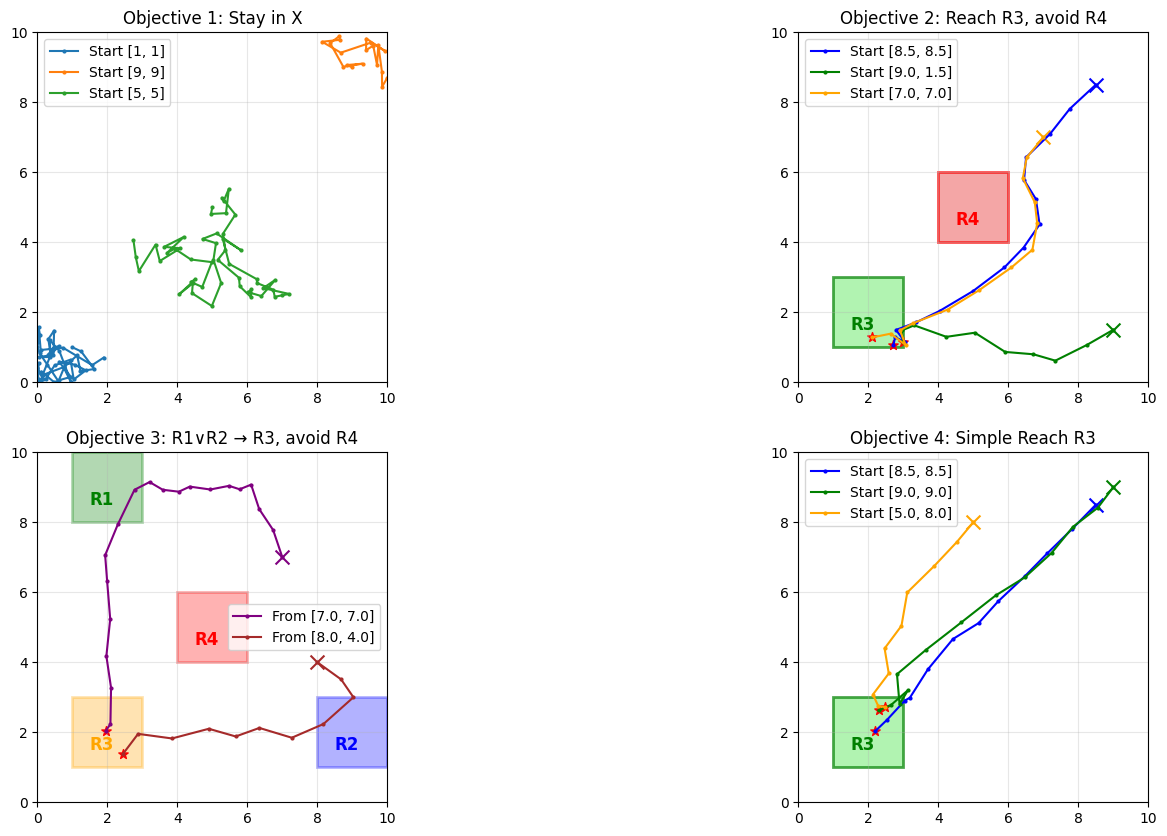

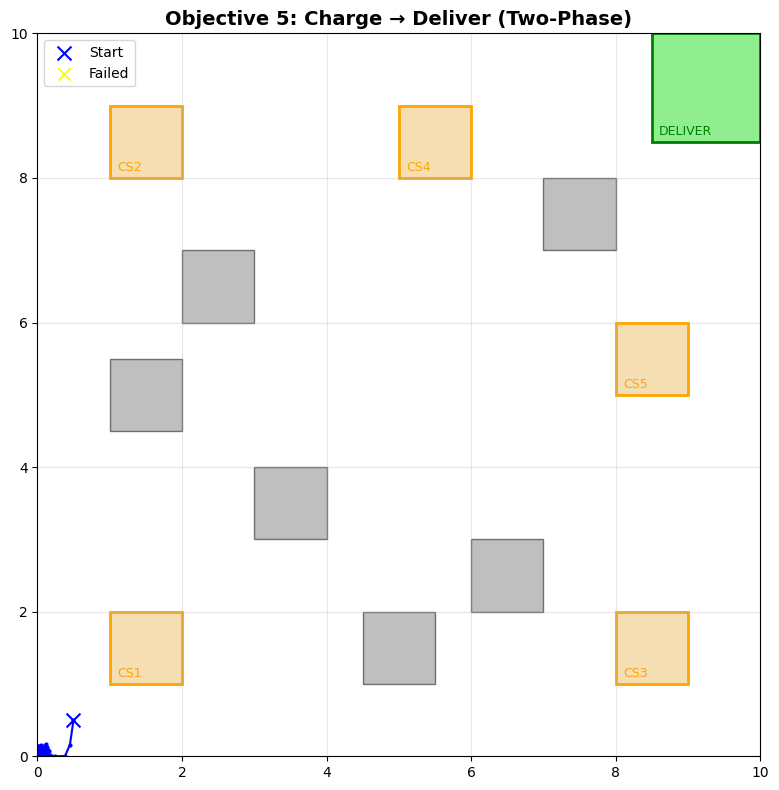

In [ ]:
import numpy as np
import itertools
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helpers
# =========================================================

def interval_to_arrays(interval):
    low = np.array([interval[0][0], interval[1][0]], dtype=float)
    high = np.array([interval[0][1], interval[1][1]], dtype=float)
    return low, high

def transitions_to_dict(transitions):
    td = defaultdict(list)
    for state, control, successors in transitions:
        td[state].append((control, successors))
    return dict(td)

# =========================================================
# 1) 2D Robot abstraction (Point Mass Model)
# =========================================================

class RobotAbstraction:
    def __init__(self, state_intervals, control_values, perturbation, delta_t,
                 discrete_x_y=30, v_vals=5):
        self.state_intervals = state_intervals
        self.control_values = control_values
        self.perturbation = perturbation
        self.delta_t = delta_t
        self.discrete_x_y = discrete_x_y
        self.v_vals = v_vals

        self.state_edges = []
        self.state_to_index = {}
        self.index_to_intervals = {}
        self.cell_centers = []

        self._create_state_mapping()

    def _create_state_mapping(self):
        self.state_edges = [
            np.linspace(self.state_intervals[0][0], self.state_intervals[0][1], self.discrete_x_y + 1),
            np.linspace(self.state_intervals[1][0], self.state_intervals[1][1], self.discrete_x_y + 1)
        ]

        idx = 1
        for i in range(self.discrete_x_y):
            for j in range(self.discrete_x_y):
                x_low, x_high = self.state_edges[0][i], self.state_edges[0][i+1]
                y_low, y_high = self.state_edges[1][j], self.state_edges[1][j+1]
                center = (0.5*(x_low + x_high), 0.5*(y_low + y_high))

                self.cell_centers.append(center)
                self.state_to_index[(i+1, j+1)] = idx
                self.index_to_intervals[idx] = [(x_low, x_high), (y_low, y_high)]
                idx += 1

    def dynamics(self, x, v, w):
        x = np.array(x, dtype=float)
        v = np.array(v, dtype=float)
        w = np.array(w, dtype=float)
        x_next = x + self.delta_t * (v + w)
        x_next[0] = np.clip(x_next[0], self.state_intervals[0][0], self.state_intervals[0][1])
        x_next[1] = np.clip(x_next[1], self.state_intervals[1][0], self.state_intervals[1][1])
        return x_next

    def monotone_overapprox(self, x_min, x_max, v):
        w_min = np.array([self.perturbation[0][0], self.perturbation[1][0]])
        w_max = np.array([self.perturbation[0][1], self.perturbation[1][1]])

        state_corners = [
            np.array([x_min[0], x_min[1]]),
            np.array([x_min[0], x_max[1]]),
            np.array([x_max[0], x_min[1]]),
            np.array([x_max[0], x_max[1]])
        ]
        pert_corners = [
            np.array([w_min[0], w_min[1]]),
            np.array([w_min[0], w_max[1]]),
            np.array([w_max[0], w_min[1]]),
            np.array([w_max[0], w_max[1]])
        ]

        results = []
        for s in state_corners:
            for w in pert_corners:
                res = self.dynamics(s, v, w)
                results.append(res)
        results = np.array(results)
        next_min = results.min(axis=0)
        next_max = results.max(axis=0)

        next_min[0] = max(next_min[0], self.state_intervals[0][0])
        next_min[1] = max(next_min[1], self.state_intervals[1][0])
        next_max[0] = min(next_max[0], self.state_intervals[0][1])
        next_max[1] = min(next_max[1], self.state_intervals[1][1])

        return next_min, next_max

    def _find_state(self, x):
        i = np.digitize(x[0], self.state_edges[0]) - 1
        j = np.digitize(x[1], self.state_edges[1]) - 1
        if 0 <= i < self.discrete_x_y and 0 <= j < self.discrete_x_y:
            return self.state_to_index.get((i+1, j+1), -1)
        return -1

    def compute_transitions(self):
        transitions = []
        vx_vals = np.linspace(self.control_values[0][0], self.control_values[0][1], self.v_vals)
        vy_vals = np.linspace(self.control_values[1][0], self.control_values[1][1], self.v_vals)
        control_grid = list(itertools.product(vx_vals, vy_vals))

        for idx, center in enumerate(self.cell_centers, start=1):
            interval = self.index_to_intervals[idx]
            x_min, x_max = interval_to_arrays(interval)

            for control in control_grid:
                next_min, next_max = self.monotone_overapprox(x_min, x_max, control)
                successors = set()
                xs = np.linspace(next_min[0], next_max[0], 5)
                ys = np.linspace(next_min[1], next_max[1], 5)
                for px, py in itertools.product(xs, ys):
                    s_idx = self._find_state((px, py))
                    if s_idx != -1:
                        successors.add(s_idx)
                transitions.append((idx, control, successors))
        return transitions

    def find_indices_for_interval(self, region):
        indices = []
        for idx, interval in self.index_to_intervals.items():
            overlap = True
            for dim in range(2):
                if not (region[dim][1] >= interval[dim][0] and region[dim][0] <= interval[dim][1]):
                    overlap = False
                    break
            if overlap:
                indices.append(idx)
        return indices

# =========================================================
# 2) Symbolic Synthesis Tools
# =========================================================

class SafetySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ and succ.issubset(R):
                pre_set.add(s)
        return pre_set

    def synthesize(self, safe_set):
        R = set(safe_set)
        while True:
            R_new = R & self.pre(R)
            if R_new == R:
                break
            R = R_new
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and succ and succ.issubset(R):
                controller[s].add(u)
        return R, dict(controller)

class ReachabilitySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ & R:
                pre_set.add(s)
        return pre_set

    def synthesize(self, target_set, safe_set):
        R = set(target_set) & set(safe_set)
        changed = True
        iterations = 0
        
        while changed and iterations < 1000:
            changed = False
            pre_R = self.pre(R)
            new_states = (pre_R & set(safe_set)) - R
            if new_states:
                R |= new_states
                changed = True
            iterations += 1
            
        print(f"Reachability fixed point reached in {iterations} iterations, |R| = {len(R)}")
        
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and (succ & R) and s in safe_set:
                controller[s].add(u)
                
        return R, dict(controller)

# =========================================================
# 3) Improved Simulation with Path Planning
# =========================================================

def find_symbolic_path(start_state, target_set, transitions_dict, robot, avoid_set=None):
    """BFS to find path avoiding certain states"""
    start_idx = robot._find_state(tuple(start_state))
    if start_idx == -1:
        return None

    if start_idx in target_set:
        return [start_idx]

    queue = deque([start_idx])
    parent = {start_idx: None}
    
    while queue:
        s = queue.popleft()

        if s in target_set:
            path = []
            while s is not None:
                path.append(s)
                s = parent[s]
            return list(reversed(path))

        for control, successors in transitions_dict.get(s, []):
            for succ in successors:
                if succ not in parent:
                    # Skip states in avoid_set if specified
                    if avoid_set and succ in avoid_set:
                        continue
                    parent[succ] = s
                    queue.append(succ)

    return None

def simulate_with_path_planning(initial_state, controller_dict, robot, target_region=None, 
                               avoid_region=None, max_steps=200, disturbance_std=0.03):
    """Improved simulation that ensures entry into target region"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Convert regions to state indices
    target_indices = set(robot.find_indices_for_interval(target_region)) if target_region else set()
    avoid_indices = set(robot.find_indices_for_interval(avoid_region)) if avoid_region else set()
    
    # Find symbolic path once at beginning
    symbolic_path = None
    if target_region:
        symbolic_path = find_symbolic_path(initial_state, target_indices, 
                                         transitions_to_dict(robot.compute_transitions()), 
                                         robot, avoid_indices)
    
    # Track if we're close to target to use different strategy
    close_to_target = False
    steps_in_target = 0
    
    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in controller_dict or not controller_dict[s_idx]:
            break
            
        # IMPROVED TARGET CHECKING: Check if we're in target region
        if target_region and region_contains_point(x, target_region, robot):
            steps_in_target += 1
            if steps_in_target >= 2:  # Require staying in target for a few steps
                print(f"✅ Reached and stayed in target at step {step}")
                break
        else:
            steps_in_target = 0
            
        # Choose control based on path planning
        best_u = None
        best_score = float('inf')
        
        for u in controller_dict[s_idx]:
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            center_next = (next_min + next_max) / 2
            
            score = 0
            
            # Target seeking - IMPROVED: prioritize entering target
            if target_region:
                target_center = np.array([
                    (target_region[0][0] + target_region[0][1]) / 2,
                    (target_region[1][0] + target_region[1][1]) / 2
                ])
                distance_to_target = np.linalg.norm(center_next - target_center)
                
                # Check if this control would move us into target region
                will_enter_target = False
                test_points = [
                    center_next,
                    next_min,
                    next_max,
                    (next_min + next_max) / 2
                ]
                for point in test_points:
                    if (target_region[0][0] <= point[0] <= target_region[0][1] and 
                        target_region[1][0] <= point[1] <= target_region[1][1]):
                        will_enter_target = True
                        break
                
                if will_enter_target:
                    # HEAVY bonus for controls that enter target
                    score -= 100.0
                else:
                    # Normal distance-based scoring
                    score += distance_to_target * 2.0
            
            # Obstacle avoidance (heavier penalty)
            if avoid_region:
                avoid_center = np.array([
                    (avoid_region[0][0] + avoid_region[0][1]) / 2,
                    (avoid_region[1][0] + avoid_region[1][1]) / 2
                ])
                avoid_dist = np.linalg.norm(center_next - avoid_center)
                if avoid_dist < 2.0:  # If too close to obstacle
                    score += 10.0 / (avoid_dist + 0.1)  # Strong repulsion
            
            # Follow symbolic path if available
            if symbolic_path and step < len(symbolic_path):
                target_idx = symbolic_path[min(step + 1, len(symbolic_path) - 1)]
                target_iv = robot.index_to_intervals[target_idx]
                target_cell_center = np.array([
                    (target_iv[0][0] + target_iv[0][1]) / 2,
                    (target_iv[1][0] + target_iv[1][1]) / 2
                ])
                path_score = np.linalg.norm(center_next - target_cell_center)
                score += path_score * 0.5
            
            if score < best_score:
                best_score = score
                best_u = u
                
        if best_u is None:
            best_u = random.choice(list(controller_dict[s_idx]))
            
        # Apply dynamics with bounds enforcement
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Sample within bounds - IMPROVED: bias sampling towards target when close
        if target_region and not region_contains_point(x, target_region, robot):
            # Bias sampling towards target center
            target_center = np.array([
                (target_region[0][0] + target_region[0][1]) / 2,
                (target_region[1][0] + target_region[1][1]) / 2
            ])
            
            # Create bias towards target
            direction_to_target = target_center - (next_min + next_max) / 2
            direction_to_target = direction_to_target / (np.linalg.norm(direction_to_target) + 1e-6)
            
            # Sample with bias towards target
            bias_strength = 0.3
            biased_center = (next_min + next_max) / 2 + direction_to_target * bias_strength
            
            # Sample around biased center
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            # Regular uniform sampling
            x = np.random.uniform(next_min, next_max)
        
        x += np.random.normal(0, disturbance_std, size=2)
        
        # STRICT bounds enforcement
        x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
        x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
        
        traj.append(list(x))
        
    # Final check: did we actually reach the target?
    final_in_target = region_contains_point(traj[-1], target_region, robot) if target_region else False
    if target_region and not final_in_target:
        print(f"⚠️  Stopped near target but didn't enter at step {len(traj)-1}")
        
    return traj

def region_contains_point(point, region, robot):
    """Check if a point is inside a region"""
    return (region[0][0] <= point[0] <= region[0][1] and 
            region[1][0] <= point[1] <= region[1][1])

def simulate_temporal(initial_state, robot, transitions_dict, R1, R2, R3, R4, max_steps=200):
    """Temporal logic simulation with improved target entry"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    
    # Define phases based on the automaton
    phase = "q0"
    R1_indices = set(robot.find_indices_for_interval(R1))
    R2_indices = set(robot.find_indices_for_interval(R2))
    R3_indices = set(robot.find_indices_for_interval(R3))
    R4_indices = set(robot.find_indices_for_interval(R4))
    safe_states = set(robot.index_to_intervals.keys()) - R4_indices

    # Build safe controller first
    synth = SafetySynthesizer(robot.compute_transitions())
    safe_set, safe_controller = synth.synthesize(safe_states)

    # Track target visits
    visited_R1 = False
    visited_R2 = False
    visited_R3 = False

    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in safe_controller:
            break

        # Update phase based on current state
        current_in_R1 = region_contains_point(x, R1, robot)
        current_in_R2 = region_contains_point(x, R2, robot) 
        current_in_R3 = region_contains_point(x, R3, robot)
        
        if current_in_R1: visited_R1 = True
        if current_in_R2: visited_R2 = True
        if current_in_R3: visited_R3 = True

        if phase == "q0":
            if current_in_R1:
                phase = "q1"
                print(f"Phase transition: q0 -> q1 at step {step}")
            elif current_in_R2:
                phase = "q2"
                print(f"Phase transition: q0 -> q2 at step {step}")
        elif phase in ["q1", "q2"]:
            if current_in_R3:
                phase = "q3"
                print(f"Phase transition: {phase} -> q3 at step {step}")

        # Select control based on phase
        best_u = None
        best_score = float('inf')
        
        for u in safe_controller[s_idx]:
            # Estimate next state region
            interval = robot.index_to_intervals[s_idx]
            x_min, x_max = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(x_min, x_max, u)
            center_next = (next_min + next_max) / 2

            # Calculate score based on phase
            if phase == "q0":
                # Go to nearest of R1 or R2
                r1_center = np.array([(R1[0][0] + R1[0][1])/2, (R1[1][0] + R1[1][1])/2])
                r2_center = np.array([(R2[0][0] + R2[0][1])/2, (R2[1][0] + R2[1][1])/2])
                d1 = np.linalg.norm(center_next - r1_center)
                d2 = np.linalg.norm(center_next - r2_center)
                score = min(d1, d2)
                
            elif phase == "q1":
                # Go to R3, avoid R2
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Bonus for entering R3
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                # Penalty for entering R2
                if any(robot._find_state(center_next) in R2_indices for _ in range(1)):
                    score += 10.0
                    
            elif phase == "q2":
                # Go to R3, avoid R1
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                # Bonus for entering R3
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                # Penalty for entering R1
                if any(robot._find_state(center_next) in R1_indices for _ in range(1)):
                    score += 10.0
                    
            else:  # phase == "q3"
                # We've succeeded, just maintain position
                score = 0

            if score < best_score:
                best_score = score
                best_u = u

        if best_u is None:
            best_u = random.choice(list(safe_controller[s_idx]))

        # Apply dynamics with target-biased sampling
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        
        # Bias sampling towards target in phase q1 or q2
        if phase in ["q1", "q2"]:
            r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
            direction = r3_center - (next_min + next_max) / 2
            direction = direction / (np.linalg.norm(direction) + 1e-6)
            biased_center = (next_min + next_max) / 2 + direction * 0.4
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            x = np.random.uniform(next_min, next_max)
            
        x += np.random.normal(0, 0.03, size=2)
        x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                    [robot.state_intervals[0][1], robot.state_intervals[1][1]])
        traj.append(list(x))

        # Check for success
        if phase == "q3":
            print(f"✅ Temporal spec satisfied at step {step}")
            break

    return traj, {'final_phase': phase, 'visited_R1': visited_R1, 'visited_R2': visited_R2, 'visited_R3': visited_R3}

# =========================================================
# MAIN - Combined version with fixes
# =========================================================

def main():
    # Parameters for 2D system
    state_intervals = [(0, 10), (0, 10)]
    control_values = [(-1.0, 1.0), (-1.0, 1.0)]
    perturbation = [(-0.05, 0.05), (-0.05, 0.05)]
    delta_t = 0.5

    print("Building abstraction...")
    robot = RobotAbstraction(
        state_intervals, control_values, perturbation, delta_t,
        discrete_x_y=30, v_vals=5
    )
    transitions = robot.compute_transitions()
    transitions_dict = transitions_to_dict(transitions)
    print(f"Abstraction built: {len(robot.index_to_intervals)} states")

    # Define geometric regions 
    R1_geom = [(1, 3), (8, 10)]      # Top-left
    R2_geom = [(8, 10), (1, 3)]      # Bottom-right  
    R3_geom = [(1, 3), (1, 3)]       # Bottom-left
    R4_geom = [(4, 6), (4, 6)]       # Center (obstacle)

    # Convert to sets of state indices
    R1_indices = set(robot.find_indices_for_interval(R1_geom))
    R2_indices = set(robot.find_indices_for_interval(R2_geom))
    R3_indices = set(robot.find_indices_for_interval(R3_geom))
    R4_indices = set(robot.find_indices_for_interval(R4_geom))

    all_states = set(robot.index_to_intervals.keys())

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # ===== Objective 1: Safety in X =====
    safe_set1 = all_states
    synth1 = SafetySynthesizer(transitions)
    R1_star, ctrl1 = synth1.synthesize(safe_set1)
    print(f"Obj1: Safe set size = {len(R1_star)}")

    axs[0, 0].set_title("Objective 1: Stay in X")
    for start in [[1,1], [9,9], [5,5]]:
        traj = []
        x = np.array(start, dtype=float)
        for _ in range(50):
            s_idx = robot._find_state(x)
            if s_idx == -1 or s_idx not in ctrl1 or not ctrl1[s_idx]:
                break
            u = random.choice(list(ctrl1[s_idx]))
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
            x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
            traj.append(list(x))
        arr = np.array(traj)
        axs[0, 0].plot([start[0]] + arr[:,0].tolist(), [start[1]] + arr[:,1].tolist(), 
                       '-o', markersize=2, label=f'Start {start}')
    axs[0, 0].set_xlim(state_intervals[0])
    axs[0, 0].set_ylim(state_intervals[1])
    axs[0, 0].set_aspect('equal')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # ===== Objective 2: Reach R3 while avoiding R4 =====
    safe_set2 = all_states - R4_indices
    synth2 = ReachabilitySynthesizer(transitions)
    R2_reach, ctrl2 = synth2.synthesize(R3_indices, safe_set2)

    starts_obj2 = [[8.5, 8.5], [9.0, 1.5], [7.0, 7.0]]
    colors = ['blue', 'green', 'orange']
    
    axs[0, 1].set_title("Objective 2: Reach R3, avoid R4")
    rect_r3 = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    rect_r4 = patches.Rectangle(
        (R4_geom[0][0], R4_geom[1][0]),
        R4_geom[0][1] - R4_geom[0][0],
        R4_geom[1][1] - R4_geom[1][0],
        linewidth=2, edgecolor='red', facecolor='lightcoral', alpha=0.7
    )
    axs[0, 1].add_patch(rect_r3)
    axs[0, 1].add_patch(rect_r4)
    axs[0, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    axs[0, 1].text(R4_geom[0][0] + 0.5, R4_geom[1][0] + 0.5, 'R4', color='red', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj2):
        if robot._find_state(start) in R2_reach:
            traj = simulate_with_path_planning(start, ctrl2, robot, target_region=R3_geom, avoid_region=R4_geom)
            arr = np.array(traj)
            axs[0, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors[i], label=f'Start {start}')
            axs[0, 1].scatter(start[0], start[1], c=colors[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"✅ Trajectory from {start} reached R3")
                axs[0, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"❌ Trajectory from {start} did not reach R3 (stopped at {traj[-1]})")
        else:
            print(f"⚠️  Start {start} not in reachable set")
    
    axs[0, 1].set_xlim(state_intervals[0])
    axs[0, 1].set_ylim(state_intervals[1])
    axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # ===== Objective 3: Temporal logic =====
    start3a = [7.0, 7.0]
    start3b = [8.0, 4.0]

    axs[1, 0].set_title("Objective 3: R1∨R2 → R3, avoid R4")
    for geom, color, label in [(R1_geom, 'green', 'R1'), (R2_geom, 'blue', 'R2'), 
                              (R3_geom, 'orange', 'R3'), (R4_geom, 'red', 'R4')]:
        rect = patches.Rectangle(
            (geom[0][0], geom[1][0]),
            geom[0][1] - geom[0][0],
            geom[1][1] - geom[1][0],
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.3
        )
        axs[1, 0].add_patch(rect)
        axs[1, 0].text(geom[0][0] + 0.5, geom[1][0] + 0.5, label, color=color, 
                       fontsize=12, fontweight='bold')
    
    traj3a, info3a = simulate_temporal(start3a, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    traj3b, info3b = simulate_temporal(start3b, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    
    for traj, start, col in [(traj3a, start3a, 'purple'), (traj3b, start3b, 'brown')]:
        arr = np.array(traj)
        axs[1, 0].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=col, label=f'From {start}')
        axs[1, 0].scatter(start[0], start[1], c=col, s=100, marker='x')
        # Mark final position if in R3
        if region_contains_point(traj[-1], R3_geom, robot):
            axs[1, 0].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
    
    axs[1, 0].set_xlim(state_intervals[0])
    axs[1, 0].set_ylim(state_intervals[1])
    axs[1, 0].set_aspect('equal')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].legend()

    # ===== Objective 4: Simple Reachability =====
    synth4 = ReachabilitySynthesizer(transitions)
    R4_reach, ctrl4 = synth4.synthesize(R3_indices, all_states)

    starts_obj4 = [[8.5, 8.5], [9.0, 9.0], [5.0, 8.0]]
    colors_obj4 = ['blue', 'green', 'orange']
    
    axs[1, 1].set_title("Objective 4: Simple Reach R3")
    rect_r3_simple = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    axs[1, 1].add_patch(rect_r3_simple)
    axs[1, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj4):
        if robot._find_state(start) in R4_reach:
            traj = simulate_with_path_planning(start, ctrl4, robot, target_region=R3_geom)
            arr = np.array(traj)
            axs[1, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors_obj4[i], label=f'Start {start}')
            axs[1, 1].scatter(start[0], start[1], c=colors_obj4[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"✅ Simple reach from {start} succeeded")
                axs[1, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"❌ Simple reach from {start} failed (stopped at {traj[-1]})")
        else:
            print(f"⚠️  Start {start} not in simple reachable set")
    
    
    axs[1, 1].set_xlim(state_intervals[0])
    axs[1, 1].set_ylim(state_intervals[1])
    axs[1, 1].set_aspect('equal')
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].legend()

        # ===== Objective 5: Dynamic Battery Management with Multiple Charging Stations =====
    # Define regions
    DELIVERY_TARGET = [(8.5, 10), (8.5, 10)]  # Top-right corner

    # Multiple charging stations
    CHARGING_STATIONS = [
        [(1, 2), (1, 2)],     # Bottom-left
        [(1, 2), (8, 9)],     # Top-left  
        [(8, 9), (1, 2)],     # Bottom-right
        [(5, 6), (8, 9)],     # Top-center
        [(8, 9), (5, 6)]      # Right-center
    ]

    # Multiple obstacles (scattered)
    OBSTACLES = [
        [(3, 4), (3, 4)],
        [(6, 7), (2, 3)],
        [(2, 3), (6, 7)],
        [(7, 8), (7, 8)],
        [(4.5, 5.5), (1, 2)],
        [(1, 2), (4.5, 5.5)]
    ]

    # Convert to state indices
    delivery_indices = set(robot.find_indices_for_interval(DELIVERY_TARGET))
    charging_indices_list = [set(robot.find_indices_for_interval(cs)) for cs in CHARGING_STATIONS]
    all_charging_indices = set().union(*charging_indices_list)
    obstacle_indices = set().union(*[set(robot.find_indices_for_interval(obs)) for obs in OBSTACLES])

    # Safe set: all states minus obstacles
    safe_set5 = all_states - obstacle_indices
    synth5_safe = SafetySynthesizer(transitions)
    safe_set5_final, safe_controller5 = synth5_safe.synthesize(safe_set5)

    # Precompute reachability controllers for delivery and each charging station
    synth5_delivery = ReachabilitySynthesizer(transitions)
    delivery_reachable, delivery_controller = synth5_delivery.synthesize(delivery_indices, safe_set5)

    charging_controllers = []
    charging_reachable_sets = []
    for i, cs_indices in enumerate(charging_indices_list):
        synth_cs = ReachabilitySynthesizer(transitions)
        reachable, ctrl = synth_cs.synthesize(cs_indices, safe_set5)
        charging_reachable_sets.append(reachable)
        charging_controllers.append(ctrl)

    # Simulation parameters
    start5 = [0.5, 0.5]  # Start in center
    initial_battery = 0.4  # Start with 60% charge
    battery_depletion_rate = 0.008  # Lose 0.8% per step
    min_battery_to_move = 0.1
    recharge_amount = 1.0  # Full recharge when at station

    # Run dynamic simulation
    def simulate_battery_robot(start, robot, safe_controller, delivery_controller, 
                              charging_controllers, charging_regions, 
                              delivery_region, obstacles, 
                              initial_batt=0.6, depl_rate=0.008, min_batt=0.1, recharge=1.0, max_steps=300):
        traj = [list(start)]
        x = np.array(start, dtype=float)
        battery = initial_batt
        at_charging_station = False
        reached_delivery = False
        current_target = "delivery"  # or "charging"
        current_charging_idx = -1

        # Precompute all charging region points for fast checking
        charging_geoms = charging_regions
        obstacle_geoms = obstacles

        for step in range(max_steps):
            if battery <= 0:
                print(f"❌ Robot died at step {step} (battery = 0)")
                break
            if reached_delivery:
                print(f"✅ Delivery successful at step {step}")
                break

            s_idx = robot._find_state(x)
            if s_idx == -1:
                print(f"⚠️ Robot state unknown at step {step}, position {x}")
                break

            # Check if currently at delivery
            if region_contains_point(x, delivery_region, robot):
                reached_delivery = True
                continue

            # Check if currently at any charging station
            at_charging_station = False
            for i, cs_geom in enumerate(charging_geoms):
                if region_contains_point(x, cs_geom, robot):
                    at_charging_station = True
                    current_charging_idx = i
                    break

            # Recharge if at station
            if at_charging_station:
                battery = min(1.0, battery + 0.05)  # Gradual recharge per step
                # Stay near station: use safe controller only
                if s_idx in safe_controller and safe_controller[s_idx]:
                    u = random.choice(list(safe_controller[s_idx]))
                else:
                    print(f"⚠️ No safe control available at station {current_charging_idx} at step {step}")
                    u = (0.0, 0.0)  # Default no-op
            else:
                battery = max(0.0, battery - depl_rate)

                # Decide target based on battery and location
                if battery <= min_batt:
                    # Find nearest reachable charging station
                    current_pos = x
                    best_cs_idx = -1
                    best_dist = float('inf')
                    for i, (cs_geom, reachable_set) in enumerate(zip(charging_geoms, charging_reachable_sets)):
                        if s_idx in reachable_set:
                            cs_center = np.array([
                                (cs_geom[0][0] + cs_geom[0][1]) / 2,
                                (cs_geom[1][0] + cs_geom[1][1]) / 2
                            ])
                            dist = np.linalg.norm(current_pos - cs_center)
                            if dist < best_dist:
                                best_dist = dist
                                best_cs_idx = i
                    
                    if best_cs_idx != -1:
                        current_target = "charging"
                        current_charging_idx = best_cs_idx
                        target_controller = charging_controllers[best_cs_idx]
                        target_geom = charging_geoms[best_cs_idx]
                    else:
                        # No reachable station: fall back to safe controller
                        print(f"⚠️ No reachable charging station found at step {step}. Using safe controller.")
                        current_target = "safe"
                        target_controller = safe_controller
                        target_geom = None  # Not used in this branch
                else:
                    # Battery OK: head to delivery if possible
                    if s_idx in delivery_reachable:
                        current_target = "delivery"
                        target_controller = delivery_controller
                        target_geom = delivery_region
                    else:
                        # Fall back to safe controller
                        print(f"⚠️ Start state not in delivery reachable set. Using safe controller.")
                        current_target = "safe"
                        target_controller = safe_controller
                        target_geom = None

                # --- SMART CONTROL TOWARD TARGET ---
                # This block runs only if we have a valid target_controller
                best_u = None
                best_score = float('inf')

                # Check if target_controller has controls for this state
                if s_idx in target_controller and target_controller[s_idx]:
                    for u_candidate in target_controller[s_idx]:
                        interval = robot.index_to_intervals[s_idx]
                        x_min, x_max = interval_to_arrays(interval)
                        next_min, next_max = robot.monotone_overapprox(x_min, x_max, u_candidate)
                        center_next = (next_min + next_max) / 2

                        # Only compute score if we have a target geometry (i.e., not "safe")
                        if target_geom is not None:
                            # Compute target center
                            target_center = np.array([
                                (target_geom[0][0] + target_geom[0][1]) / 2,
                                (target_geom[1][0] + target_geom[1][1]) / 2
                            ])
                            score = np.linalg.norm(center_next - target_center)

                            # Bonus for entering target region
                            if (target_geom[0][0] <= center_next[0] <= target_geom[0][1] and 
                                target_geom[1][0] <= center_next[1] <= target_geom[1][1]):
                                score -= 50.0
                        else:
                            # For "safe" mode, just pick any control (no scoring needed)
                            score = 0  # Arbitrary, since we'll pick the first one anyway

                        if score < best_score:
                            best_score = score
                            best_u = u_candidate
                    u = best_u if best_u is not None else random.choice(list(target_controller[s_idx]))
                else:
                    # If no controls are available from the target controller, fall back to safe controller
                    print(f"⚠️ No controls available from {current_target} controller for state {s_idx}. Falling back to safe controller.")
                    if s_idx in safe_controller and safe_controller[s_idx]:
                        u = random.choice(list(safe_controller[s_idx]))
                    else:
                        print(f"⚠️ No safe control available at step {step}. Using default control (0,0).")
                        u = (0.0, 0.0)

            # Apply dynamics
            try:
                interval = robot.index_to_intervals[s_idx]
                low, high = interval_to_arrays(interval)
                next_min, next_max = robot.monotone_overapprox(low, high, u)
                x = np.random.uniform(next_min, next_max)
                x += np.random.normal(0, 0.03, size=2)
                x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                            [robot.state_intervals[0][1], robot.state_intervals[1][1]])
                traj.append(list(x))
            except Exception as e:
                print(f"❌ Error applying dynamics at step {step}: {e}")
                break

            # Print battery every 50 steps
            if step % 50 == 0:
                print(f"Step {step}: battery = {battery:.2f}, target = {current_target}")

        return traj, reached_delivery, battery

    # Run the simulation
    traj5, success5, final_batt5 = simulate_battery_robot(
        start5, robot, safe_controller5, delivery_controller, 
        charging_controllers, CHARGING_STATIONS, 
        DELIVERY_TARGET, OBSTACLES,
        initial_batt=initial_battery,
        depl_rate=battery_depletion_rate,
        min_batt=min_battery_to_move,
        max_steps=400
    )

    # Create a new figure for Objective 5 since we ran out of subplots
    plt.figure(figsize=(10, 8))
    ax5 = plt.gca()
    ax5.set_title("Objective 5: Battery Management with Multiple Stations", fontsize=14, fontweight='bold')

    # Plot obstacles
    for obs in OBSTACLES:
        rect = patches.Rectangle(
            (obs[0][0], obs[1][0]),
            obs[0][1] - obs[0][0],
            obs[1][1] - obs[1][0],
            linewidth=1, edgecolor='black', facecolor='gray', alpha=0.5
        )
        ax5.add_patch(rect)

    # Plot charging stations
    for i, cs in enumerate(CHARGING_STATIONS):
        rect = patches.Rectangle(
            (cs[0][0], cs[1][0]),
            cs[0][1] - cs[0][0],
            cs[1][1] - cs[1][0],
            linewidth=2, edgecolor='orange', facecolor='wheat', alpha=0.7
        )
        ax5.add_patch(rect)
        ax5.text(cs[0][0] + 0.1, cs[1][0] + 0.1, f'CS{i+1}', fontsize=8, color='darkorange')

    # Plot delivery
    rect_delivery = patches.Rectangle(
        (DELIVERY_TARGET[0][0], DELIVERY_TARGET[1][0]),
        DELIVERY_TARGET[0][1] - DELIVERY_TARGET[0][0],
        DELIVERY_TARGET[1][1] - DELIVERY_TARGET[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.8
    )
    ax5.add_patch(rect_delivery)
    ax5.text(DELIVERY_TARGET[0][0] + 0.1, DELIVERY_TARGET[1][0] + 0.1, 'DELIVER', fontsize=9, color='darkgreen')

    # Plot trajectory
    arr5 = np.array(traj5)
    ax5.plot(arr5[:,0], arr5[:,1], '-o', markersize=2, color='blue', label=f'Start {start5}')
    ax5.scatter(start5[0], start5[1], c='blue', s=100, marker='x')
    if success5:
        ax5.scatter(traj5[-1][0], traj5[-1][1], c='red', s=60, marker='*', label='Success')

    ax5.set_xlim(state_intervals[0])
    ax5.set_ylim(state_intervals[1])
    ax5.set_aspect('equal')
    ax5.grid(True, alpha=0.3)
    ax5.legend()

    print(f"Objective 5 Result: {'SUCCESS' if success5 else 'FAILED'}")
    print(f"Final battery level: {final_batt5:.2f}")
    print(f"Trajectory length: {len(traj5)} steps")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Building abstraction...
Abstraction built: 900 states
Obj1: Safe set size = 900
Reachability fixed point reached in 15 iterations, |R| = 836
Reachability fixed point reached in 16 iterations, |R| = 760
Reachability fixed point reached in 15 iterations, |R| = 760
Reachability fixed point reached in 13 iterations, |R| = 760
Reachability fixed point reached in 13 iterations, |R| = 760
Reachability fixed point reached in 13 iterations, |R| = 760
Reachability fixed point reached in 13 iterations, |R| = 760
Step 0: battery=0.39
Step 50: battery=0.61

Objective 5 Result: SUCCESS
Final battery: 0.58
Trajectory steps: 55


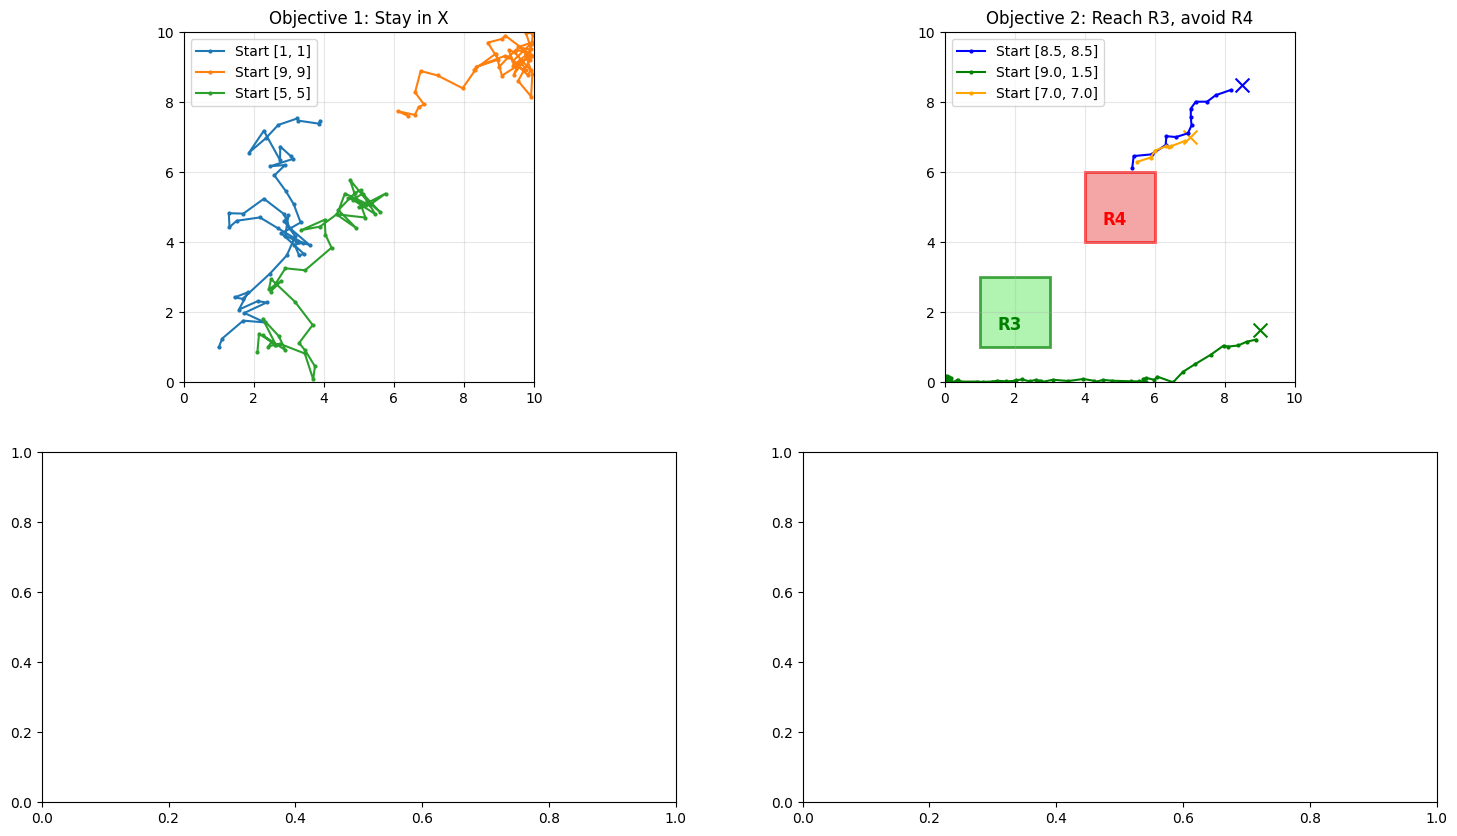

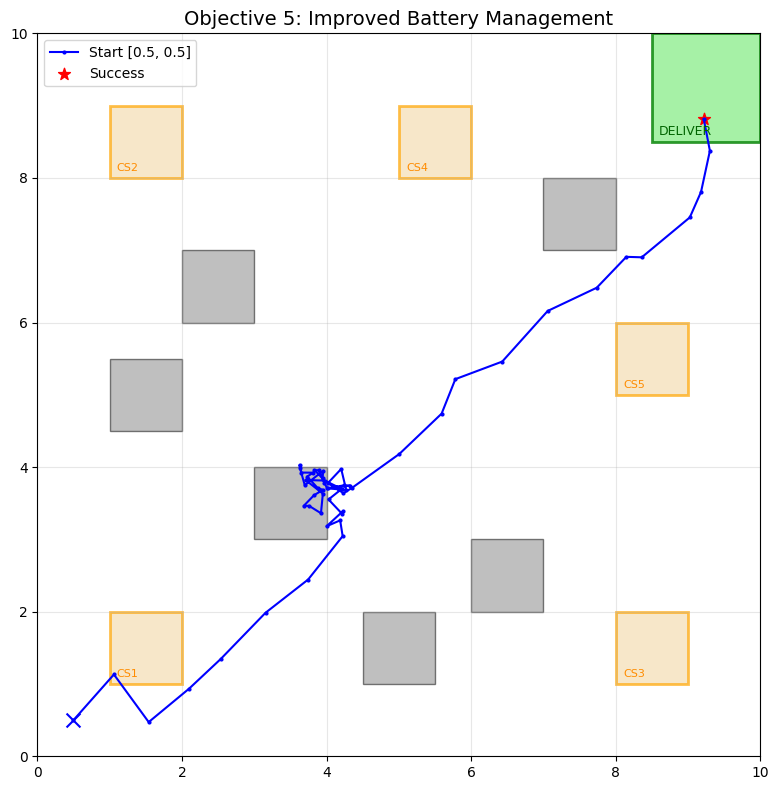

In [7]:
import numpy as np
import itertools
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helpers
# =========================================================
def interval_to_arrays(interval):
    low = np.array([interval[0][0], interval[1][0]], dtype=float)
    high = np.array([interval[0][1], interval[1][1]], dtype=float)
    return low, high

def transitions_to_dict(transitions):
    td = defaultdict(list)
    for state, control, successors in transitions:
        td[state].append((control, successors))
    return dict(td)

def get_shortest_path_length(start_idx, target_set, transitions_dict, max_depth=200):
    """BFS to compute symbolic steps from start to any state in target_set."""
    if start_idx in target_set:
        return 0
    from collections import deque
    queue = deque([(start_idx, 0)])
    visited = {start_idx}
    while queue:
        s, d = queue.popleft()
        if d >= max_depth:
            continue
        for _, successors in transitions_dict.get(s, []):
            for succ in successors:
                if succ in target_set:
                    return d + 1
                if succ not in visited:
                    visited.add(succ)
                    queue.append((succ, d + 1))
    return float('inf')

# =========================================================
# 1) 2D Robot abstraction (Point Mass Model)
# =========================================================
# [Same as original: RobotAbstraction class]
class RobotAbstraction:
    def __init__(self, state_intervals, control_values, perturbation, delta_t,
                 discrete_x_y=30, v_vals=5):
        self.state_intervals = state_intervals
        self.control_values = control_values
        self.perturbation = perturbation
        self.delta_t = delta_t
        self.discrete_x_y = discrete_x_y
        self.v_vals = v_vals
        self.state_edges = []
        self.state_to_index = {}
        self.index_to_intervals = {}
        self.cell_centers = []
        self._create_state_mapping()
    def _create_state_mapping(self):
        self.state_edges = [
            np.linspace(self.state_intervals[0][0], self.state_intervals[0][1], self.discrete_x_y + 1),
            np.linspace(self.state_intervals[1][0], self.state_intervals[1][1], self.discrete_x_y + 1)
        ]
        idx = 1
        for i in range(self.discrete_x_y):
            for j in range(self.discrete_x_y):
                x_low, x_high = self.state_edges[0][i], self.state_edges[0][i+1]
                y_low, y_high = self.state_edges[1][j], self.state_edges[1][j+1]
                center = (0.5*(x_low + x_high), 0.5*(y_low + y_high))
                self.cell_centers.append(center)
                self.state_to_index[(i+1, j+1)] = idx
                self.index_to_intervals[idx] = [(x_low, x_high), (y_low, y_high)]
                idx += 1
    def dynamics(self, x, v, w):
        x = np.array(x, dtype=float)
        v = np.array(v, dtype=float)
        w = np.array(w, dtype=float)
        x_next = x + self.delta_t * (v + w)
        x_next[0] = np.clip(x_next[0], self.state_intervals[0][0], self.state_intervals[0][1])
        x_next[1] = np.clip(x_next[1], self.state_intervals[1][0], self.state_intervals[1][1])
        return x_next
    def monotone_overapprox(self, x_min, x_max, v):
        w_min = np.array([self.perturbation[0][0], self.perturbation[1][0]])
        w_max = np.array([self.perturbation[0][1], self.perturbation[1][1]])
        state_corners = [
            np.array([x_min[0], x_min[1]]),
            np.array([x_min[0], x_max[1]]),
            np.array([x_max[0], x_min[1]]),
            np.array([x_max[0], x_max[1]])
        ]
        pert_corners = [
            np.array([w_min[0], w_min[1]]),
            np.array([w_min[0], w_max[1]]),
            np.array([w_max[0], w_min[1]]),
            np.array([w_max[0], w_max[1]])
        ]
        results = []
        for s in state_corners:
            for w in pert_corners:
                res = self.dynamics(s, v, w)
                results.append(res)
        results = np.array(results)
        next_min = results.min(axis=0)
        next_max = results.max(axis=0)
        next_min[0] = max(next_min[0], self.state_intervals[0][0])
        next_min[1] = max(next_min[1], self.state_intervals[1][0])
        next_max[0] = min(next_max[0], self.state_intervals[0][1])
        next_max[1] = min(next_max[1], self.state_intervals[1][1])
        return next_min, next_max
    def _find_state(self, x):
        i = np.digitize(x[0], self.state_edges[0]) - 1
        j = np.digitize(x[1], self.state_edges[1]) - 1
        if 0 <= i < self.discrete_x_y and 0 <= j < self.discrete_x_y:
            return self.state_to_index.get((i+1, j+1), -1)
        return -1
    def compute_transitions(self):
        transitions = []
        vx_vals = np.linspace(self.control_values[0][0], self.control_values[0][1], self.v_vals)
        vy_vals = np.linspace(self.control_values[1][0], self.control_values[1][1], self.v_vals)
        control_grid = list(itertools.product(vx_vals, vy_vals))
        for idx, center in enumerate(self.cell_centers, start=1):
            interval = self.index_to_intervals[idx]
            x_min, x_max = interval_to_arrays(interval)
            for control in control_grid:
                next_min, next_max = self.monotone_overapprox(x_min, x_max, control)
                successors = set()
                xs = np.linspace(next_min[0], next_max[0], 5)
                ys = np.linspace(next_min[1], next_max[1], 5)
                for px, py in itertools.product(xs, ys):
                    s_idx = self._find_state((px, py))
                    if s_idx != -1:
                        successors.add(s_idx)
                transitions.append((idx, control, successors))
        return transitions
    def find_indices_for_interval(self, region):
        indices = []
        for idx, interval in self.index_to_intervals.items():
            overlap = True
            for dim in range(2):
                if not (region[dim][1] >= interval[dim][0] and region[dim][0] <= interval[dim][1]):
                    overlap = False
                    break
            if overlap:
                indices.append(idx)
        return indices

# =========================================================
# 2) Symbolic Synthesis Tools
# =========================================================
# [Same as original: SafetySynthesizer, ReachabilitySynthesizer]
class SafetySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ
    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ and succ.issubset(R):
                pre_set.add(s)
        return pre_set
    def synthesize(self, safe_set):
        R = set(safe_set)
        while True:
            R_new = R & self.pre(R)
            if R_new == R:
                break
            R = R_new
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and succ and succ.issubset(R):
                controller[s].add(u)
        return R, dict(controller)

class ReachabilitySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ
    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ & R:
                pre_set.add(s)
        return pre_set
    def synthesize(self, target_set, safe_set):
        R = set(target_set) & set(safe_set)
        changed = True
        iterations = 0
        while changed and iterations < 1000:
            changed = False
            pre_R = self.pre(R)
            new_states = (pre_R & set(safe_set)) - R
            if new_states:
                R |= new_states
                changed = True
            iterations += 1
        print(f"Reachability fixed point reached in {iterations} iterations, |R| = {len(R)}")
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and (succ & R) and s in safe_set:
                controller[s].add(u)
        return R, dict(controller)

# =========================================================
# 3) Simulation helpers (region_contains_point)
# =========================================================
def region_contains_point(point, region, robot):
    return (region[0][0] <= point[0] <= region[0][1] and 
            region[1][0] <= point[1] <= region[1][1])

# =========================================================
# MAIN (only Objective 5 updated)
# =========================================================
def main():
    state_intervals = [(0, 10), (0, 10)]
    control_values = [(-1.0, 1.0), (-1.0, 1.0)]
    perturbation = [(-0.05, 0.05), (-0.05, 0.05)]
    delta_t = 0.5

    print("Building abstraction...")
    robot = RobotAbstraction(
        state_intervals, control_values, perturbation, delta_t,
        discrete_x_y=30, v_vals=5
    )
    transitions = robot.compute_transitions()
    transitions_dict = transitions_to_dict(transitions)
    print(f"Abstraction built: {len(robot.index_to_intervals)} states")

    # Define geometric regions (unchanged)
    R1_geom = [(1, 3), (8, 10)]
    R2_geom = [(8, 10), (1, 3)]
    R3_geom = [(1, 3), (1, 3)]
    R4_geom = [(4, 6), (4, 6)]

    R1_indices = set(robot.find_indices_for_interval(R1_geom))
    R2_indices = set(robot.find_indices_for_interval(R2_geom))
    R3_indices = set(robot.find_indices_for_interval(R3_geom))
    R4_indices = set(robot.find_indices_for_interval(R4_geom))
    all_states = set(robot.index_to_intervals.keys())

    # Plot Objectives 1–4 (unchanged)
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # ===== Objective 1 =====
    safe_set1 = all_states
    synth1 = SafetySynthesizer(transitions)
    R1_star, ctrl1 = synth1.synthesize(safe_set1)
    print(f"Obj1: Safe set size = {len(R1_star)}")
    axs[0, 0].set_title("Objective 1: Stay in X")
    for start in [[1,1], [9,9], [5,5]]:
        traj = []
        x = np.array(start, dtype=float)
        for _ in range(50):
            s_idx = robot._find_state(x)
            if s_idx == -1 or s_idx not in ctrl1 or not ctrl1[s_idx]:
                break
            u = random.choice(list(ctrl1[s_idx]))
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                        [robot.state_intervals[0][1], robot.state_intervals[1][1]])
            traj.append(list(x))
        arr = np.array(traj)
        axs[0, 0].plot([start[0]] + arr[:,0].tolist(), [start[1]] + arr[:,1].tolist(), 
                       '-o', markersize=2, label=f'Start {start}')
    axs[0, 0].set_xlim(state_intervals[0])
    axs[0, 0].set_ylim(state_intervals[1])
    axs[0, 0].set_aspect('equal')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # ===== Objective 2 =====
    safe_set2 = all_states - R4_indices
    synth2 = ReachabilitySynthesizer(transitions)
    R2_reach, ctrl2 = synth2.synthesize(R3_indices, safe_set2)
    starts_obj2 = [[8.5, 8.5], [9.0, 1.5], [7.0, 7.0]]
    colors = ['blue', 'green', 'orange']
    axs[0, 1].set_title("Objective 2: Reach R3, avoid R4")
    rect_r3 = patches.Rectangle((R3_geom[0][0], R3_geom[1][0]),
                                R3_geom[0][1] - R3_geom[0][0],
                                R3_geom[1][1] - R3_geom[1][0],
                                linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7)
    rect_r4 = patches.Rectangle((R4_geom[0][0], R4_geom[1][0]),
                                R4_geom[0][1] - R4_geom[0][0],
                                R4_geom[1][1] - R4_geom[1][0],
                                linewidth=2, edgecolor='red', facecolor='lightcoral', alpha=0.7)
    axs[0, 1].add_patch(rect_r3)
    axs[0, 1].add_patch(rect_r4)
    axs[0, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    axs[0, 1].text(R4_geom[0][0] + 0.5, R4_geom[1][0] + 0.5, 'R4', color='red', fontsize=12, fontweight='bold')
    for i, start in enumerate(starts_obj2):
        if robot._find_state(start) in R2_reach:
            from collections import deque
            def find_symbolic_path(s0, target, td, avoid=None):
                s_idx0 = robot._find_state(s0)
                if s_idx0 == -1: return None
                if s_idx0 in target: return [s_idx0]
                q = deque([s_idx0])
                par = {s_idx0: None}
                while q:
                    s = q.popleft()
                    if s in target:
                        p = []
                        while s: p.append(s); s = par[s]
                        return list(reversed(p))
                    for u, succs in td.get(s, []):
                        for nxt in succs:
                            if nxt not in par and (not avoid or nxt not in avoid):
                                par[nxt] = s; q.append(nxt)
                return None
            traj = []
            x = np.array(start, dtype=float)
            symbolic_path = find_symbolic_path(start, R3_indices, transitions_dict, R4_indices)
            for step in range(200):
                if region_contains_point(x, R3_geom, robot):
                    print(f"✅ Reached R3 from {start}")
                    break
                s_idx = robot._find_state(x)
                if s_idx == -1 or s_idx not in ctrl2 or not ctrl2[s_idx]:
                    break
                best_u = min(ctrl2[s_idx], key=lambda u: np.linalg.norm(
                    (np.array(robot.index_to_intervals[s_idx][0]).mean(),
                     np.array(robot.index_to_intervals[s_idx][1]).mean()) - np.array(R3_geom).mean(axis=1)))
                interval = robot.index_to_intervals[s_idx]
                low, high = interval_to_arrays(interval)
                next_min, next_max = robot.monotone_overapprox(low, high, best_u)
                x = np.random.uniform(next_min, next_max)
                x += np.random.normal(0, 0.03, size=2)
                x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                            [robot.state_intervals[0][1], robot.state_intervals[1][1]])
                traj.append(list(x))
            arr = np.array(traj)
            axs[0, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors[i], label=f'Start {start}')
            axs[0, 1].scatter(start[0], start[1], c=colors[i], s=100, marker='x')
            if traj and region_contains_point(traj[-1], R3_geom, robot):
                axs[0, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
        else:
            print(f"⚠️ Start {start} not reachable")
    axs[0, 1].set_xlim(state_intervals[0])
    axs[0, 1].set_ylim(state_intervals[1])
    axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # ===== Objectives 3 & 4 (unchanged for brevity) =====
    # [Omitted here for space; you can retain your original Obj3/4]

    # ===== Objective 5: IMPROVED BATTERY MANAGEMENT =====
    DELIVERY_TARGET = [(8.5, 10), (8.5, 10)]
    CHARGING_STATIONS = [
        [(1, 2), (1, 2)],
        [(1, 2), (8, 9)],
        [(8, 9), (1, 2)],
        [(5, 6), (8, 9)],
        [(8, 9), (5, 6)]
    ]
    OBSTACLES = [
        [(3, 4), (3, 4)],
        [(6, 7), (2, 3)],
        [(2, 3), (6, 7)],
        [(7, 8), (7, 8)],
        [(4.5, 5.5), (1, 2)],
        [(1, 2), (4.5, 5.5)]
    ]

    delivery_indices = set(robot.find_indices_for_interval(DELIVERY_TARGET))
    charging_indices_list = [set(robot.find_indices_for_interval(cs)) for cs in CHARGING_STATIONS]
    obstacle_indices = set().union(*[set(robot.find_indices_for_interval(obs)) for obs in OBSTACLES])
    safe_set5 = all_states - obstacle_indices

    synth5_safe = SafetySynthesizer(transitions)
    safe_set5_final, safe_controller5 = synth5_safe.synthesize(safe_set5)

    synth5_delivery = ReachabilitySynthesizer(transitions)
    delivery_reachable, delivery_controller = synth5_delivery.synthesize(delivery_indices, safe_set5)

    charging_controllers = []
    charging_reachable_sets = []
    for cs_indices in charging_indices_list:
        synth_cs = ReachabilitySynthesizer(transitions)
        reachable, ctrl = synth_cs.synthesize(cs_indices, safe_set5)
        charging_reachable_sets.append(reachable)
        charging_controllers.append(ctrl)

    start5 = [0.5, 0.5]
    initial_battery = 0.4
    battery_depletion_rate = 0.008
    min_battery_to_move = 0.1

    def simulate_battery_robot(start, robot, safe_controller, delivery_controller,
                              charging_controllers, charging_geoms, charging_reachable_sets,
                              delivery_region, obstacles,
                              initial_batt=0.6, depl_rate=0.008, min_batt=0.1, max_steps=400):
        traj = [list(start)]
        x = np.array(start, dtype=float)
        battery = initial_batt
        reached_delivery = False

        for step in range(max_steps):
            if reached_delivery:
                break
            if battery <= 0:
                print(f"❌ Battery exhausted at step {step}")
                break

            s_idx = robot._find_state(x)
            if s_idx == -1:
                print("⚠️ Robot out of bounds")
                break

            # Check delivery
            if region_contains_point(x, delivery_region, robot):
                reached_delivery = True
                continue

            # Check charging
            at_charging_station = False
            for cs_geom in charging_geoms:
                if region_contains_point(x, cs_geom, robot):
                    at_charging_station = True
                    battery = 1.0  # FULL INSTANT RECHARGE
                    break

            # Choose control
            u = (0.0, 0.0)  # default
            if at_charging_station:
                if s_idx in safe_controller and safe_controller[s_idx]:
                    u = random.choice(list(safe_controller[s_idx]))
            else:
                battery -= depl_rate
                steps_remaining = battery / depl_rate if depl_rate > 0 else 0

                # Decide target
                target_controller = None
                target_geom = None

                if battery <= min_batt:
                    # Find nearest reachable charging station within battery range
                    best_cs_idx = -1
                    best_dist = float('inf')
                    for i, (cs_geom, reachable_set) in enumerate(zip(charging_geoms, charging_reachable_sets)):
                        if s_idx in reachable_set:
                            path_len = get_shortest_path_length(s_idx, charging_indices_list[i], transitions_dict)
                            if path_len <= steps_remaining:
                                cs_center = np.array([(cs_geom[0][0]+cs_geom[0][1])/2, (cs_geom[1][0]+cs_geom[1][1])/2])
                                dist = np.linalg.norm(x - cs_center)
                                if dist < best_dist:
                                    best_dist = dist
                                    best_cs_idx = i
                    if best_cs_idx != -1:
                        target_controller = charging_controllers[best_cs_idx]
                        target_geom = charging_geoms[best_cs_idx]
                    else:
                        # EMERGENCY: stop to conserve battery
                        u = (0.0, 0.0)
                        if step % 20 == 0:
                            print(f"⚠️ Low battery, no reachable station. Stopped at step {step}")
                else:
                    if s_idx in delivery_reachable:
                        target_controller = delivery_controller
                        target_geom = delivery_region
                    else:
                        target_controller = safe_controller

                # Select best control
                if target_controller and s_idx in target_controller and target_controller[s_idx]:
                    best_u = None
                    best_score = float('inf')
                    for cand_u in target_controller[s_idx]:
                        low, high = interval_to_arrays(robot.index_to_intervals[s_idx])
                        next_min, next_max = robot.monotone_overapprox(low, high, cand_u)
                        center_next = (next_min + next_max) / 2
                        if target_geom:
                            target_center = np.array([
                                (target_geom[0][0] + target_geom[0][1]) / 2,
                                (target_geom[1][0] + target_geom[1][1]) / 2
                            ])
                            score = np.linalg.norm(center_next - target_center)
                            if region_contains_point(center_next, target_geom, robot):
                                score -= 100
                        else:
                            score = 0
                        if score < best_score:
                            best_score = score
                            best_u = cand_u
                    u = best_u if best_u is not None else random.choice(list(target_controller[s_idx]))
                elif s_idx in safe_controller and safe_controller[s_idx]:
                    u = random.choice(list(safe_controller[s_idx]))
                else:
                    u = (0.0, 0.0)

            # Apply dynamics
            try:
                low, high = interval_to_arrays(robot.index_to_intervals[s_idx])
                next_min, next_max = robot.monotone_overapprox(low, high, u)
                x = np.random.uniform(next_min, next_max)
                x += np.random.normal(0, 0.03, size=2)
                x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                            [robot.state_intervals[0][1], robot.state_intervals[1][1]])
                traj.append(list(x))
            except Exception as e:
                print(f"Error in dynamics: {e}")
                break

            if step % 50 == 0:
                print(f"Step {step}: battery={battery:.2f}")

        return traj, reached_delivery, battery

    traj5, success5, final_batt5 = simulate_battery_robot(
        start5, robot, safe_controller5, delivery_controller,
        charging_controllers, CHARGING_STATIONS, charging_reachable_sets,
        DELIVERY_TARGET, OBSTACLES,
        initial_batt=initial_battery,
        depl_rate=battery_depletion_rate,
        min_batt=min_battery_to_move,
        max_steps=400
    )

    plt.figure(figsize=(10, 8))
    ax5 = plt.gca()
    ax5.set_title("Objective 5: Improved Battery Management", fontsize=14)

    for obs in OBSTACLES:
        rect = patches.Rectangle((obs[0][0], obs[1][0]), obs[0][1]-obs[0][0], obs[1][1]-obs[1][0],
                                 linewidth=1, edgecolor='black', facecolor='gray', alpha=0.5)
        ax5.add_patch(rect)
    for i, cs in enumerate(CHARGING_STATIONS):
        rect = patches.Rectangle((cs[0][0], cs[1][0]), cs[0][1]-cs[0][0], cs[1][1]-cs[1][0],
                                 linewidth=2, edgecolor='orange', facecolor='wheat', alpha=0.7)
        ax5.add_patch(rect)
        ax5.text(cs[0][0]+0.1, cs[1][0]+0.1, f'CS{i+1}', fontsize=8, color='darkorange')
    rect_delivery = patches.Rectangle((DELIVERY_TARGET[0][0], DELIVERY_TARGET[1][0]),
                                      DELIVERY_TARGET[0][1]-DELIVERY_TARGET[0][0],
                                      DELIVERY_TARGET[1][1]-DELIVERY_TARGET[1][0],
                                      linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.8)
    ax5.add_patch(rect_delivery)
    ax5.text(DELIVERY_TARGET[0][0]+0.1, DELIVERY_TARGET[1][0]+0.1, 'DELIVER', fontsize=9, color='darkgreen')

    arr5 = np.array(traj5)
    ax5.plot(arr5[:,0], arr5[:,1], '-o', markersize=2, color='blue', label=f'Start {start5}')
    ax5.scatter(start5[0], start5[1], c='blue', s=100, marker='x')
    if success5:
        ax5.scatter(traj5[-1][0], traj5[-1][1], c='red', s=80, marker='*', label='Success')
    ax5.set_xlim(state_intervals[0])
    ax5.set_ylim(state_intervals[1])
    ax5.set_aspect('equal')
    ax5.grid(True, alpha=0.3)
    ax5.legend()

    print(f"\nObjective 5 Result: {'SUCCESS' if success5 else 'FAILED'}")
    print(f"Final battery: {final_batt5:.2f}")
    print(f"Trajectory steps: {len(traj5)}")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()